# V3 프로모션 × 인구통계 서브그룹 SHAP 분석

**분석 구조:**
```
전체 데이터
├── 프로모션=0 (일반 가입)
│   ├── 남자 / 여자
│   ├── 10대 / 20대 / ... / 70대
│   └── 10대남자 / 10대여자 / ... / 70대남자 / 70대여자
└── 프로모션=1 (프로모션 가입)
    ├── 남자 / 여자
    ├── 10대 / 20대 / ... / 70대
    └── 10대남자 / 10대여자 / ... / 70대남자 / 70대여자
```

> VIF+SHAP으로 확정된 정제 변수셋을 공통으로 사용합니다.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import shap

BASE = Path('../..').resolve()
SEED = 42

df = pd.read_csv(
    BASE / '_data/02_interim/260513 feature/Membership_v3.csv',
    encoding='utf-8-sig'
)
print(f'V3 shape: {df.shape}')

V3 shape: (23343, 91)


In [3]:
EXCLUDE = [
    'USER_KEY', 'product_code', 'payment_device',
    'gender', 'reg_date', 'end_date', 'is_repurchase',
    'billing_method', 'price', 'max_screen', 'age',
    'reg_hour'
]
EXCLUDE = [c for c in EXCLUDE if c in df.columns]

df_enc = df.copy()
for col in df_enc.select_dtypes('object').columns:
    if col not in EXCLUDE:
        df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

FEAT_ALL = [c for c in df_enc.columns if c not in EXCLUDE]
X_all    = df_enc[FEAT_ALL].fillna(0)
y_all    = df_enc['is_repurchase']

print(f'전체 변수: {len(FEAT_ALL)}개')
print(f'프로모션=0: {(df_enc["is_promotion"]==0).sum():,}명')
print(f'프로모션=1: {(df_enc["is_promotion"]==1).sum():,}명')

전체 변수: 79개
프로모션=0: 11,388명
프로모션=1: 11,955명


In [4]:
def calc_vif(X_df):
    Xv = X_df.select_dtypes(include=[np.number]).copy()
    Xv = Xv.drop(columns=[c for c in Xv.columns if Xv[c].var() == 0])
    Xv.insert(0, 'const', 1)
    vals = Xv.values.astype(float)
    result = []
    for i in range(1, len(Xv.columns)):
        try:
            v = variance_inflation_factor(vals, i)
        except Exception:
            v = np.inf
        result.append({'변수': Xv.columns[i], 'VIF': v})
    return pd.DataFrame(result)

# 전체 데이터로 기준 모델 -> SHAP 중요도 확보
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)
spw = (y_tr==0).sum() / (y_tr==1).sum()
m_full = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=SEED, n_jobs=-1, verbosity=0
)
m_full.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
print(f'[전체 기준] AUC={roc_auc_score(y_te, m_full.predict_proba(X_te)[:,1]):.4f}')

shap_imp = pd.DataFrame({
    '변수': FEAT_ALL,
    'SHAP': np.abs(shap.TreeExplainer(m_full).shap_values(X_te)).mean(axis=0)
}).sort_values('SHAP', ascending=False)
shap_dict = dict(zip(shap_imp['변수'], shap_imp['SHAP']))

# VIF+SHAP 반복 제거
FEAT_REF = FEAT_ALL.copy()
removed  = []
while True:
    vif_df   = calc_vif(X_all[FEAT_REF])
    high_vif = vif_df[np.isinf(vif_df['VIF']) | (vif_df['VIF'] > 10)].copy()
    if len(high_vif) == 0:
        break
    high_vif['SHAP'] = high_vif['변수'].map(shap_dict).fillna(0)
    target = high_vif.sort_values('SHAP').iloc[0]
    FEAT_REF.remove(target['변수'])
    removed.append(target['변수'])

X_ref = X_all[FEAT_REF]
print(f'정제 완료: {len(FEAT_ALL)}개 -> {len(FEAT_REF)}개  ({len(removed)}개 제거)')

[전체 기준] AUC=0.8839
정제 완료: 79개 -> 61개  (18개 제거)


In [5]:
AGE_GROUPS = [10, 20, 30, 40, 50, 60, 70]
MIN_SAMPLES = 150

# 프로모션별 서브그룹 정의
# 구조: {prom_label: {group_name: mask}}
prom_masks = {
    '프로모션=0': df_enc['is_promotion'] == 0,
    '프로모션=1': df_enc['is_promotion'] == 1,
}

all_subgroups = {}  # {'프로모션=0 / 남자': mask, ...}

for plabel, pmask in prom_masks.items():
    # 성별
    for g, glabel in [('M','남자'), ('F','여자')]:
        mask = pmask & (df_enc['gender'] == g)
        all_subgroups[f'{plabel} / {glabel}'] = mask.values

    # 연령대
    for age in AGE_GROUPS:
        mask = pmask & (df_enc['age_group'] == age)
        all_subgroups[f'{plabel} / {age}대'] = mask.values

    # 성별 x 연령대
    for age in AGE_GROUPS:
        for g, glabel in [('M','남자'), ('F','여자')]:
            mask = pmask & (df_enc['age_group'] == age) & (df_enc['gender'] == g)
            all_subgroups[f'{plabel} / {age}대 {glabel}'] = mask.values

# 샘플 수 확인
print(f'{"그룹":<35} {"전체":>6} {"이탈":>6} {"재구매":>6} {"사용":>5}')
print('-' * 62)
for name, mask in all_subgroups.items():
    n  = mask.sum()
    n0 = (y_all[mask] == 0).sum()
    n1 = (y_all[mask] == 1).sum()
    ok = 'O' if (n >= MIN_SAMPLES and n0 >= 30 and n1 >= 30) else 'X'
    print(f'{name:<35} {n:>6,} {n0:>6,} {n1:>6,} {ok:>5}')

그룹                                      전체     이탈    재구매    사용
--------------------------------------------------------------
프로모션=0 / 남자                          2,763    707  2,056     O
프로모션=0 / 여자                          5,058  1,198  3,860     O
프로모션=0 / 10대                           123     28     95     X
프로모션=0 / 20대                         2,392    607  1,785     O
프로모션=0 / 30대                         2,341    595  1,746     O
프로모션=0 / 40대                         5,894  1,350  4,544     O
프로모션=0 / 50대                           440    120    320     O
프로모션=0 / 60대                           169     38    131     O
프로모션=0 / 70대                            29      8     21     X
프로모션=0 / 10대 남자                         43     11     32     X
프로모션=0 / 10대 여자                         78     16     62     X
프로모션=0 / 20대 남자                        689    187    502     O
프로모션=0 / 20대 여자                      1,635    408  1,227     O
프로모션=0 / 30대 남자                        883    232    65

In [6]:
def run_shap(X_g, y_g):
    valid_cols = [c for c in FEAT_REF if X_g[c].var() > 0]
    Xv = X_g[valid_cols]
    spw_g = (y_g==0).sum() / max((y_g==1).sum(), 1)
    m = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        scale_pos_weight=spw_g, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0
    )
    if len(Xv) >= 400:
        Xtr, Xte, ytr, yte = train_test_split(Xv, y_g, test_size=0.2, stratify=y_g, random_state=SEED)
        m.fit(Xtr, ytr, eval_set=[(Xte, yte)], verbose=False)
        auc = roc_auc_score(yte, m.predict_proba(Xte)[:,1])
        sv  = np.abs(shap.TreeExplainer(m).shap_values(Xte)).mean(axis=0)
    else:
        m.fit(Xv, y_g, verbose=False)
        auc = roc_auc_score(y_g, m.predict_proba(Xv)[:,1])
        sv  = np.abs(shap.TreeExplainer(m).shap_values(Xv)).mean(axis=0)
    s = pd.Series(0.0, index=FEAT_REF)
    s[valid_cols] = sv
    return s, auc

shap_results = {}
auc_results  = {}

for name, mask in all_subgroups.items():
    X_g = X_ref[mask].reset_index(drop=True)
    y_g = y_all[mask].reset_index(drop=True)
    n0, n1 = (y_g==0).sum(), (y_g==1).sum()
    if len(X_g) < MIN_SAMPLES or n0 < 30 or n1 < 30:
        continue
    s, auc = run_shap(X_g, y_g)
    shap_results[name] = s
    auc_results[name]  = auc
    print(f'[완료] {name:<35}  n={len(X_g):,}  AUC={auc:.4f}')

print(f'\n총 {len(shap_results)}개 그룹 분석 완료')

[완료] 프로모션=0 / 남자                          n=2,763  AUC=0.8585
[완료] 프로모션=0 / 여자                          n=5,058  AUC=0.8719
[완료] 프로모션=0 / 20대                         n=2,392  AUC=0.8561
[완료] 프로모션=0 / 30대                         n=2,341  AUC=0.8692
[완료] 프로모션=0 / 40대                         n=5,894  AUC=0.8633
[완료] 프로모션=0 / 50대                         n=440  AUC=0.8854
[완료] 프로모션=0 / 60대                         n=169  AUC=0.9973
[완료] 프로모션=0 / 20대 남자                      n=689  AUC=0.8392
[완료] 프로모션=0 / 20대 여자                      n=1,635  AUC=0.8494
[완료] 프로모션=0 / 30대 남자                      n=883  AUC=0.8522
[완료] 프로모션=0 / 30대 여자                      n=1,408  AUC=0.8517
[완료] 프로모션=0 / 40대 남자                      n=856  AUC=0.8758
[완료] 프로모션=0 / 40대 여자                      n=1,608  AUC=0.8219
[완료] 프로모션=0 / 50대 남자                      n=191  AUC=0.9986
[완료] 프로모션=0 / 50대 여자                      n=233  AUC=0.9990
[완료] 프로모션=1 / 남자                          n=4,561  AUC=0.8562
[완료] 프로모션=1 / 여자      

## 프로모션=0 vs 프로모션=1 내 성별 비교

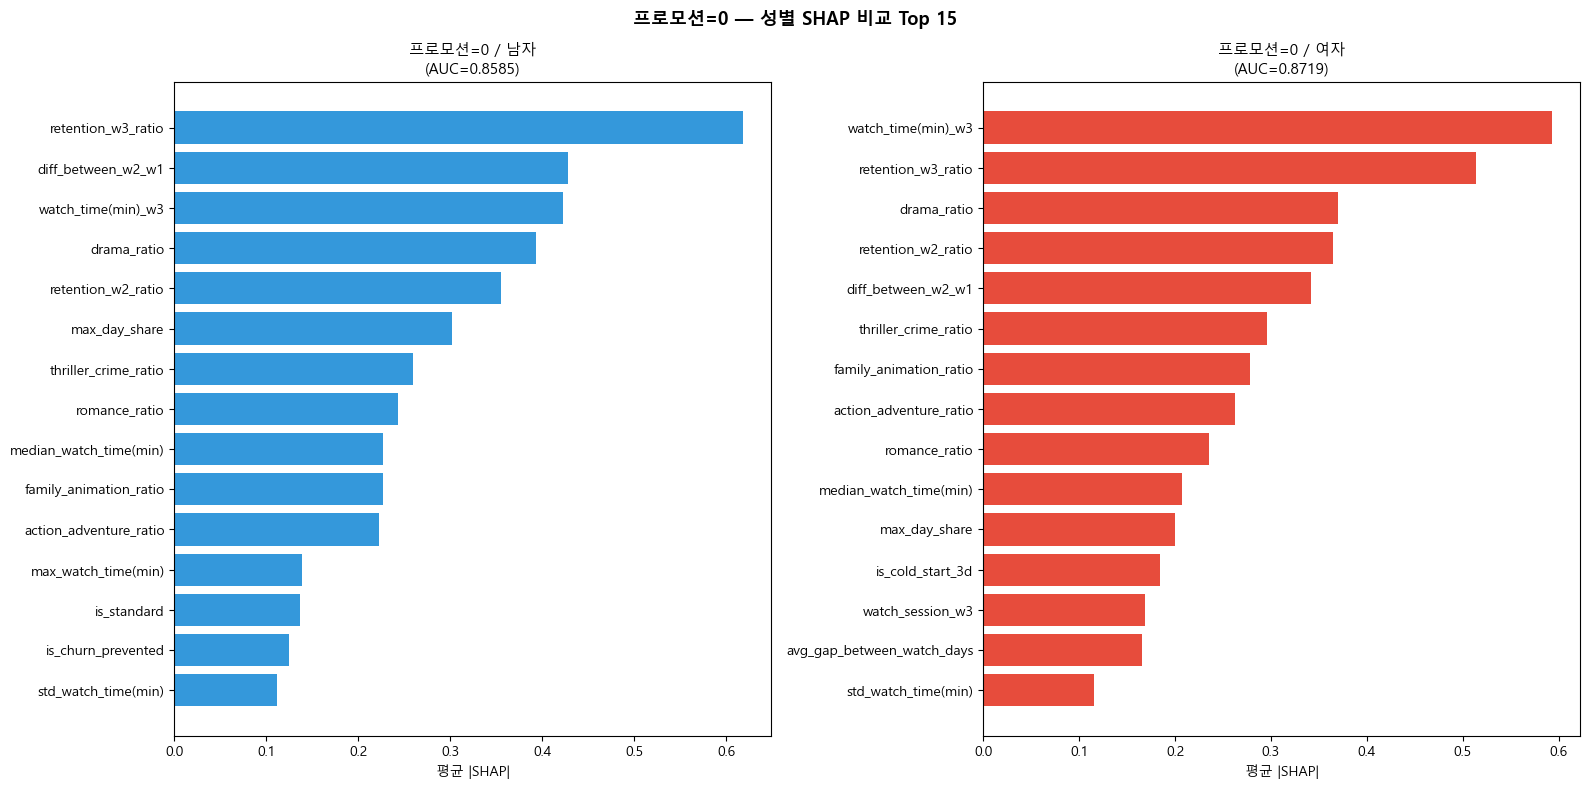


=== 프로모션=0 성별 SHAP 차이 ===
                                  남자        여자   차이(남-여)
watch_time(min)_w3          0.422057  0.592768 -0.170711
watch_session_w3            0.050283  0.168296 -0.118013
retention_w3_ratio          0.617561  0.514208  0.103353
max_day_share               0.301742  0.200295  0.101447
avg_gap_between_watch_days  0.073797  0.165932 -0.092135
diff_between_w2_w1          0.428243  0.342279  0.085963
is_cold_start_3d            0.105442  0.183952 -0.078510
max_watch_time(min)         0.138329  0.063027  0.075302
is_standard                 0.136768  0.065893  0.070875
family_animation_ratio      0.226234  0.277786 -0.051551


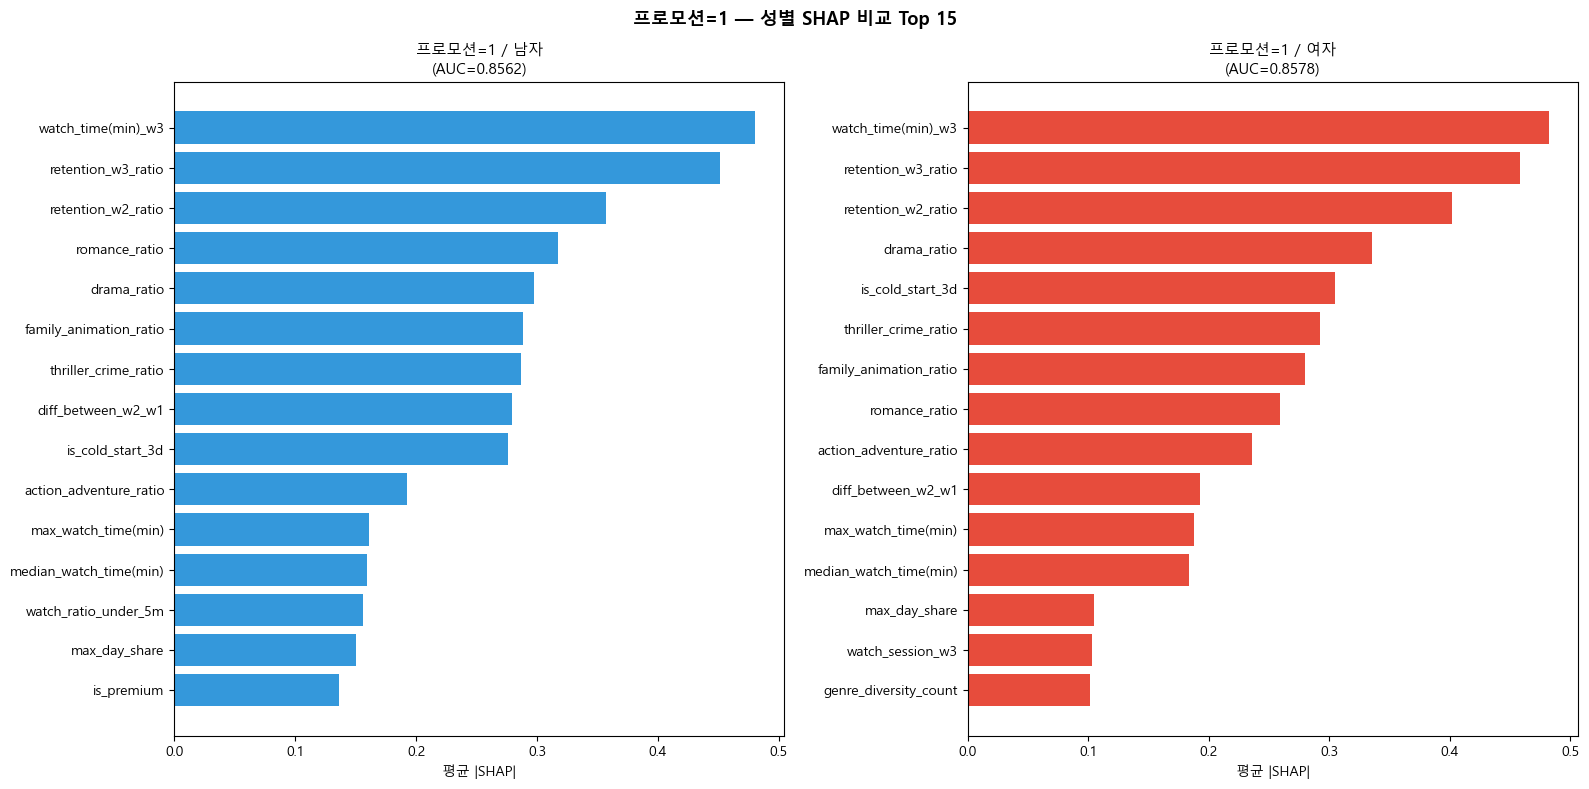


=== 프로모션=1 성별 SHAP 차이 ===
                              남자        여자   차이(남-여)
watch_ratio_under_5m    0.156220  0.036321  0.119899
diff_between_w2_w1      0.279431  0.193003  0.086428
avg_gap_w3_watch_days   0.109674  0.039202  0.070472
is_premium              0.135836  0.077301  0.058535
romance_ratio           0.317077  0.259045  0.058033
max_day_share           0.150440  0.104489  0.045950
retention_w2_ratio      0.356875  0.402039 -0.045164
action_adventure_ratio  0.192351  0.236267 -0.043916
is_w3_over_50pct        0.053151  0.010921  0.042230
new_movie_in_90d_ratio  0.079769  0.039262  0.040506


In [7]:
for plabel in ['프로모션=0', '프로모션=1']:
    gender_names = [f'{plabel} / 남자', f'{plabel} / 여자']
    available    = [n for n in gender_names if n in shap_results]
    if len(available) < 2:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, name in zip(axes, available):
        top = shap_results[name].sort_values().tail(15)
        color = '#3498db' if '남자' in name else '#e74c3c'
        ax.barh(top.index, top.values, color=color)
        ax.set_title(f'{name}\n(AUC={auc_results[name]:.4f})', fontsize=11)
        ax.set_xlabel('평균 |SHAP|')
    plt.suptitle(f'{plabel} — 성별 SHAP 비교 Top 15', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # 차이 테이블
    comp = pd.DataFrame({
        '남자': shap_results[f'{plabel} / 남자'],
        '여자': shap_results[f'{plabel} / 여자'],
    })
    comp['차이(남-여)'] = comp['남자'] - comp['여자']
    comp = comp.sort_values('차이(남-여)', key=abs, ascending=False)
    print(f'\n=== {plabel} 성별 SHAP 차이 ===')
    print(comp.head(10).to_string())

## 프로모션별 연령대 비교

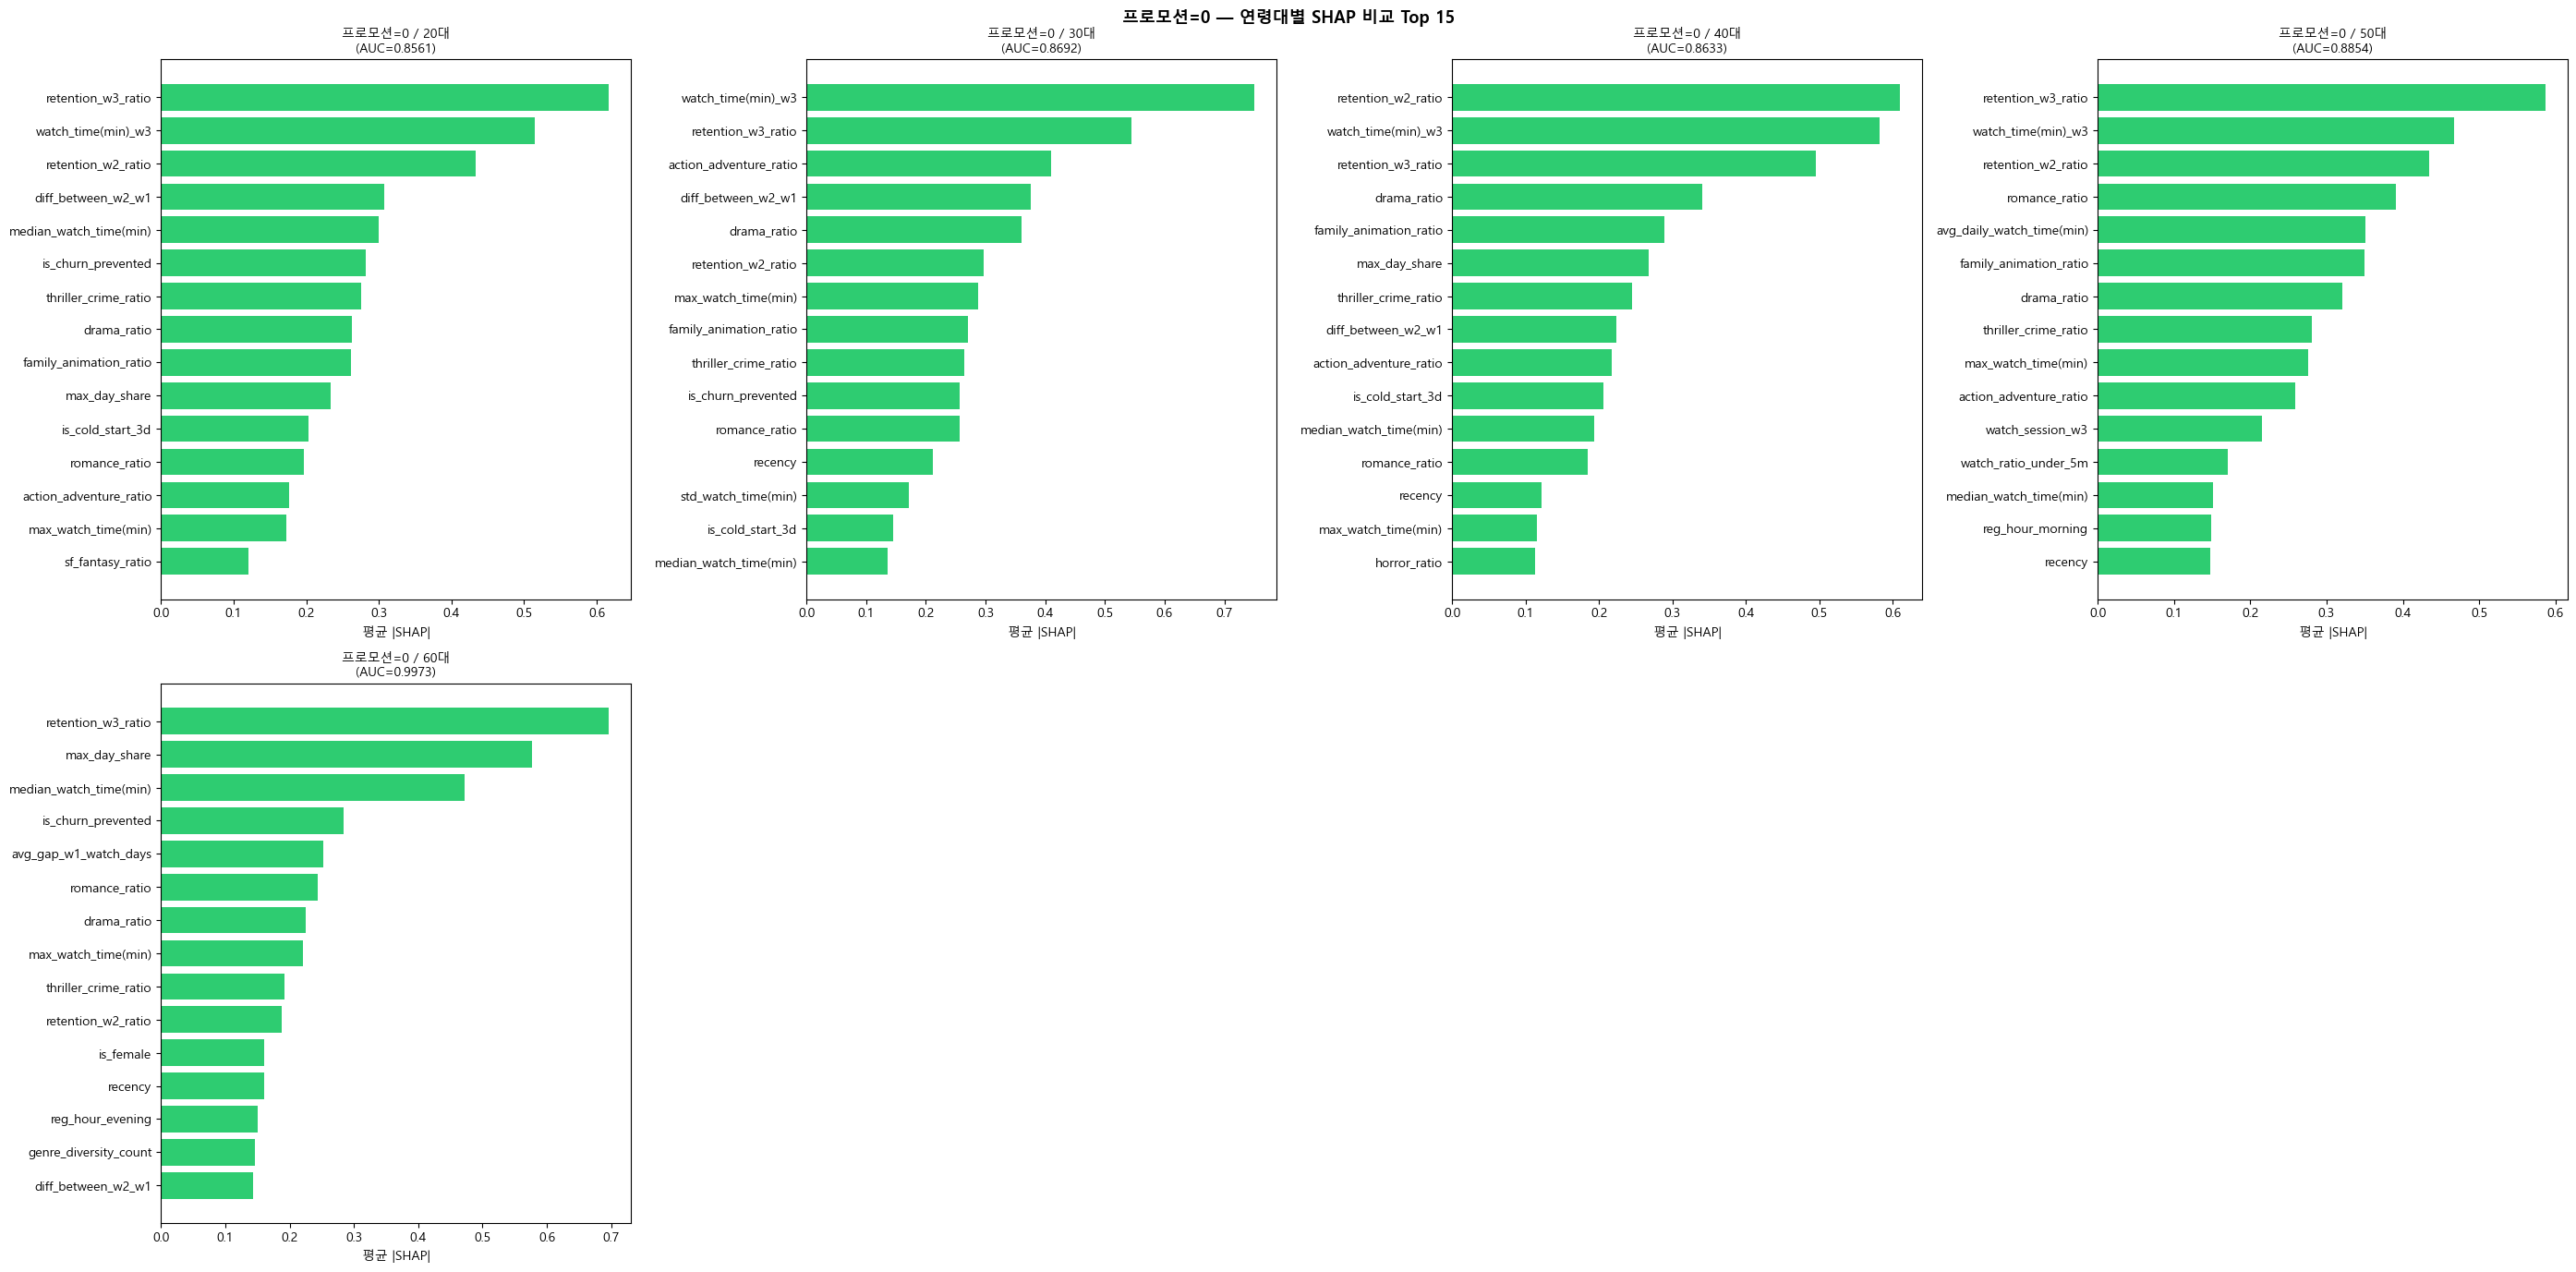

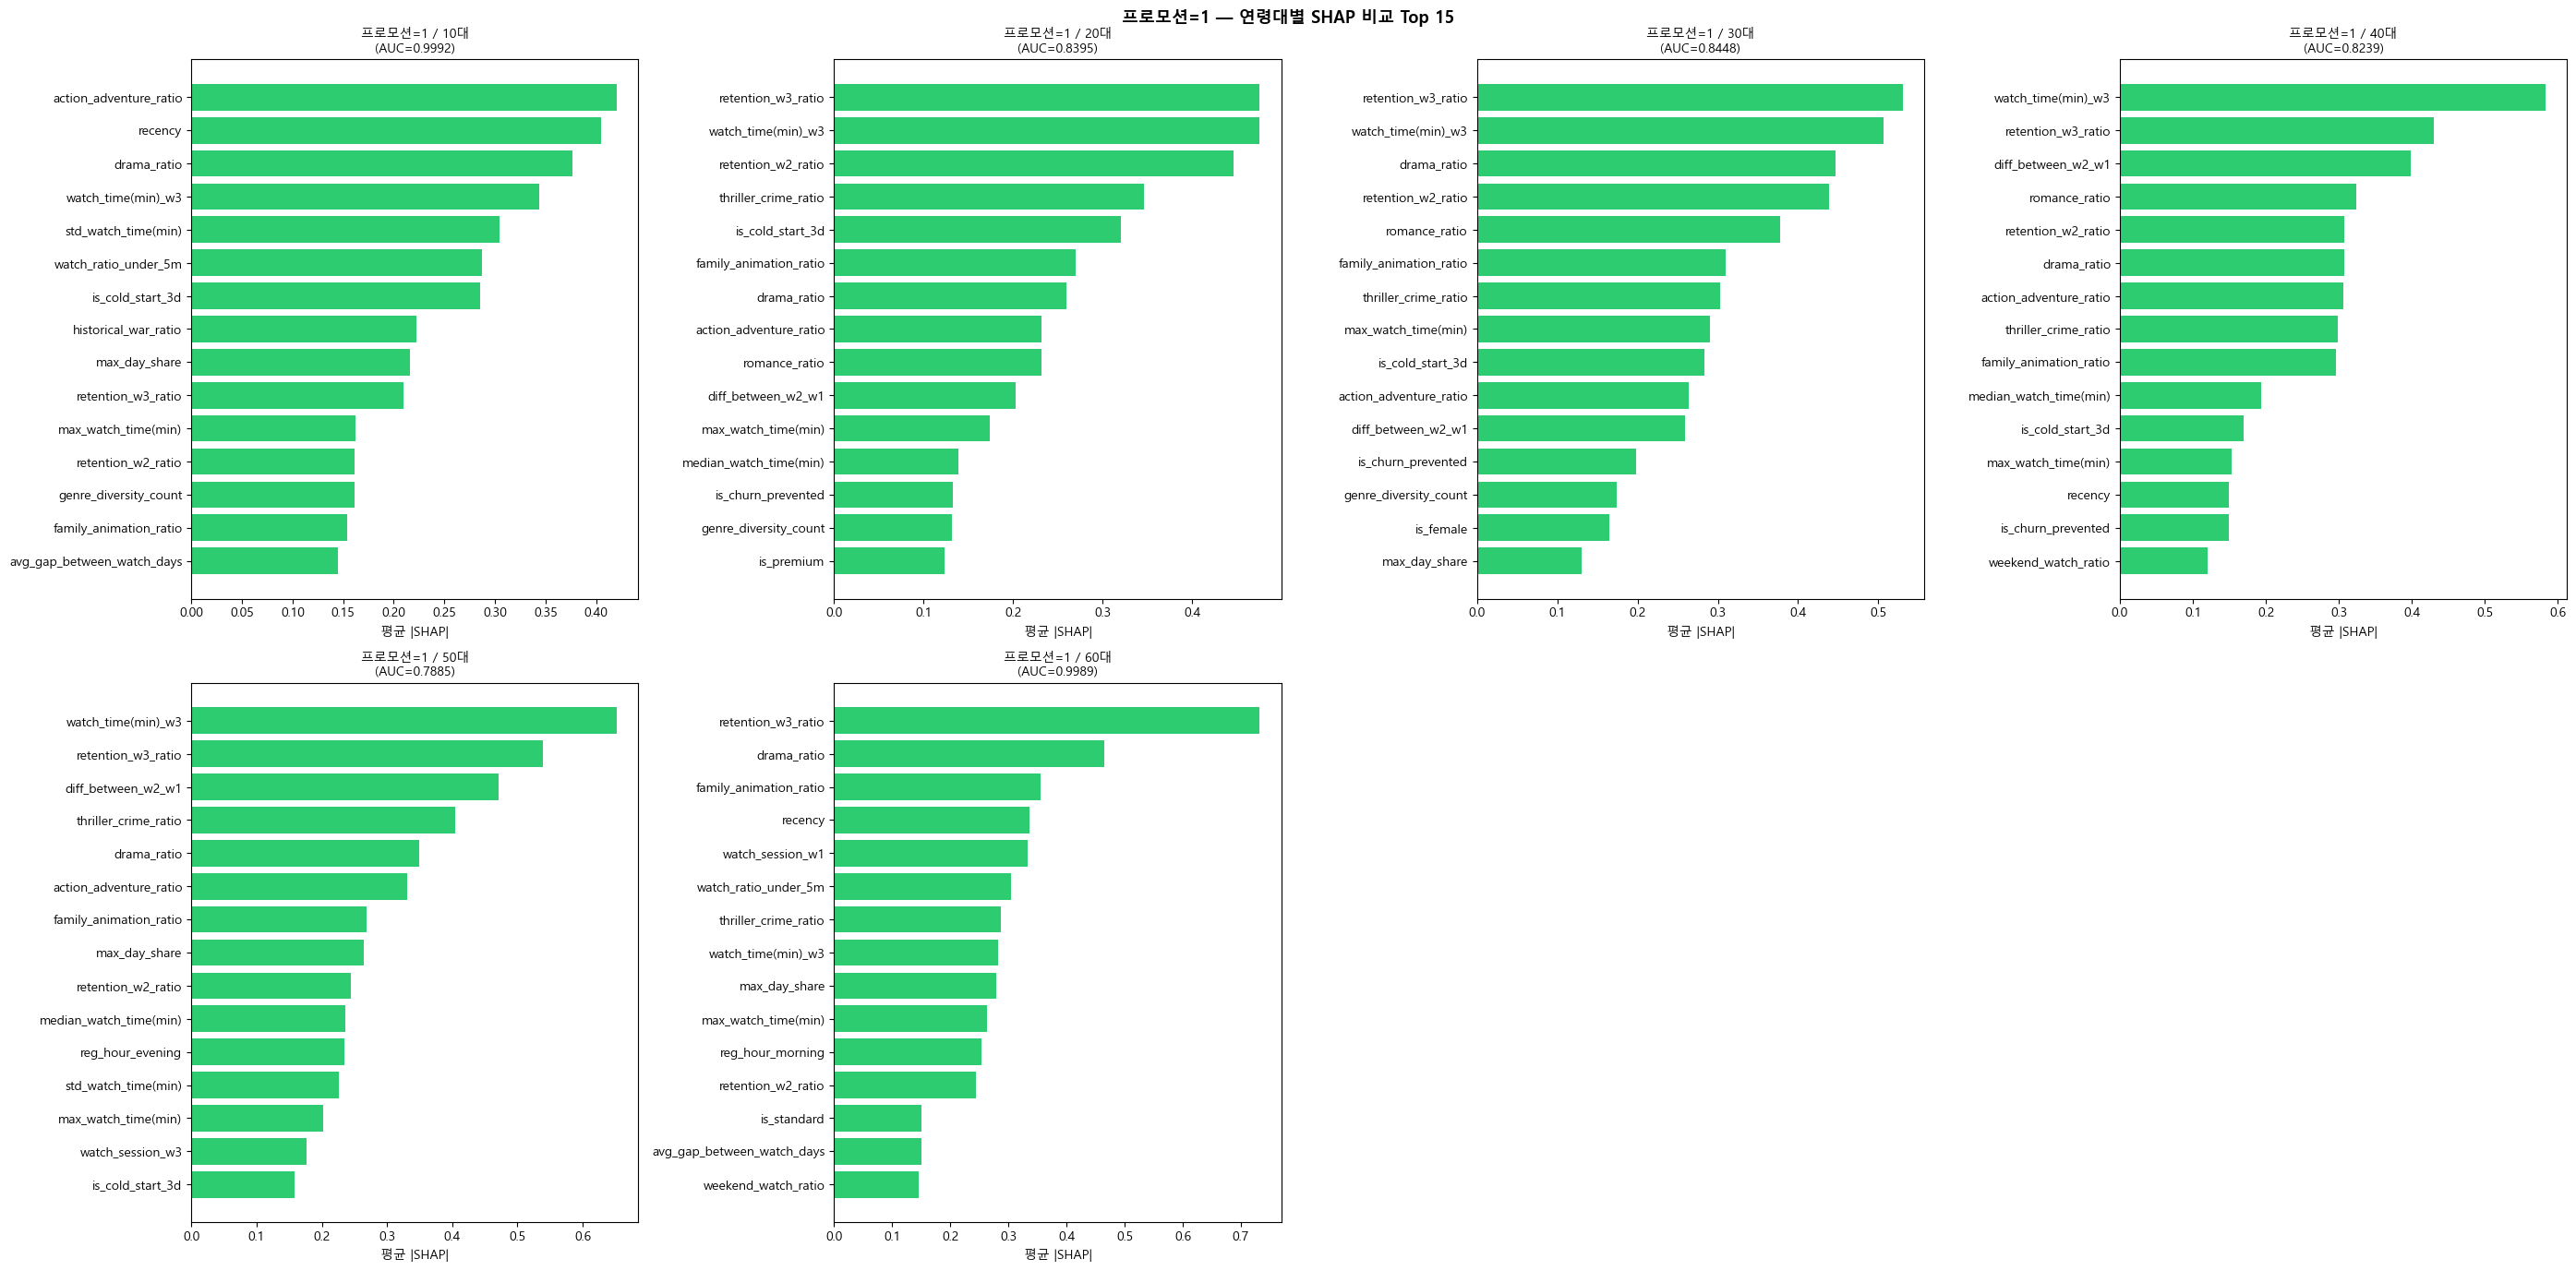

In [8]:
for plabel in ['프로모션=0', '프로모션=1']:
    age_names = [f'{plabel} / {a}대' for a in AGE_GROUPS if f'{plabel} / {a}대' in shap_results]
    if not age_names:
        continue

    fig, axes = plt.subplots(2, 4, figsize=(28, 14))
    axes = axes.flatten()
    for i, name in enumerate(age_names):
        top = shap_results[name].sort_values().tail(15)
        axes[i].barh(top.index, top.values, color='#2ecc71')
        axes[i].set_title(f'{name}\n(AUC={auc_results[name]:.4f})', fontsize=10)
        axes[i].set_xlabel('평균 |SHAP|')
    for j in range(len(age_names), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'{plabel} — 연령대별 SHAP 비교 Top 15', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## 통합 히트맵 — 프로모션×성별×연령대

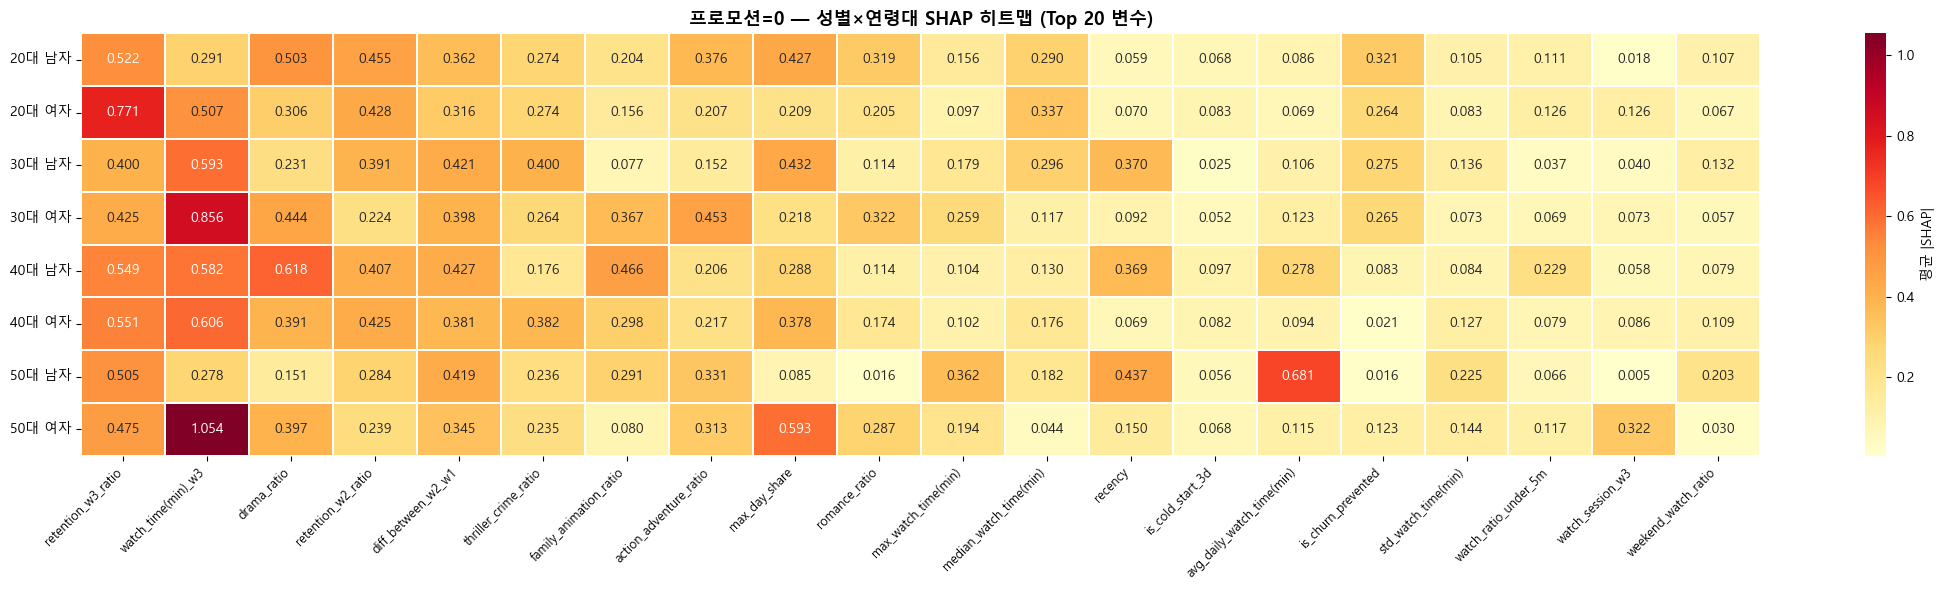

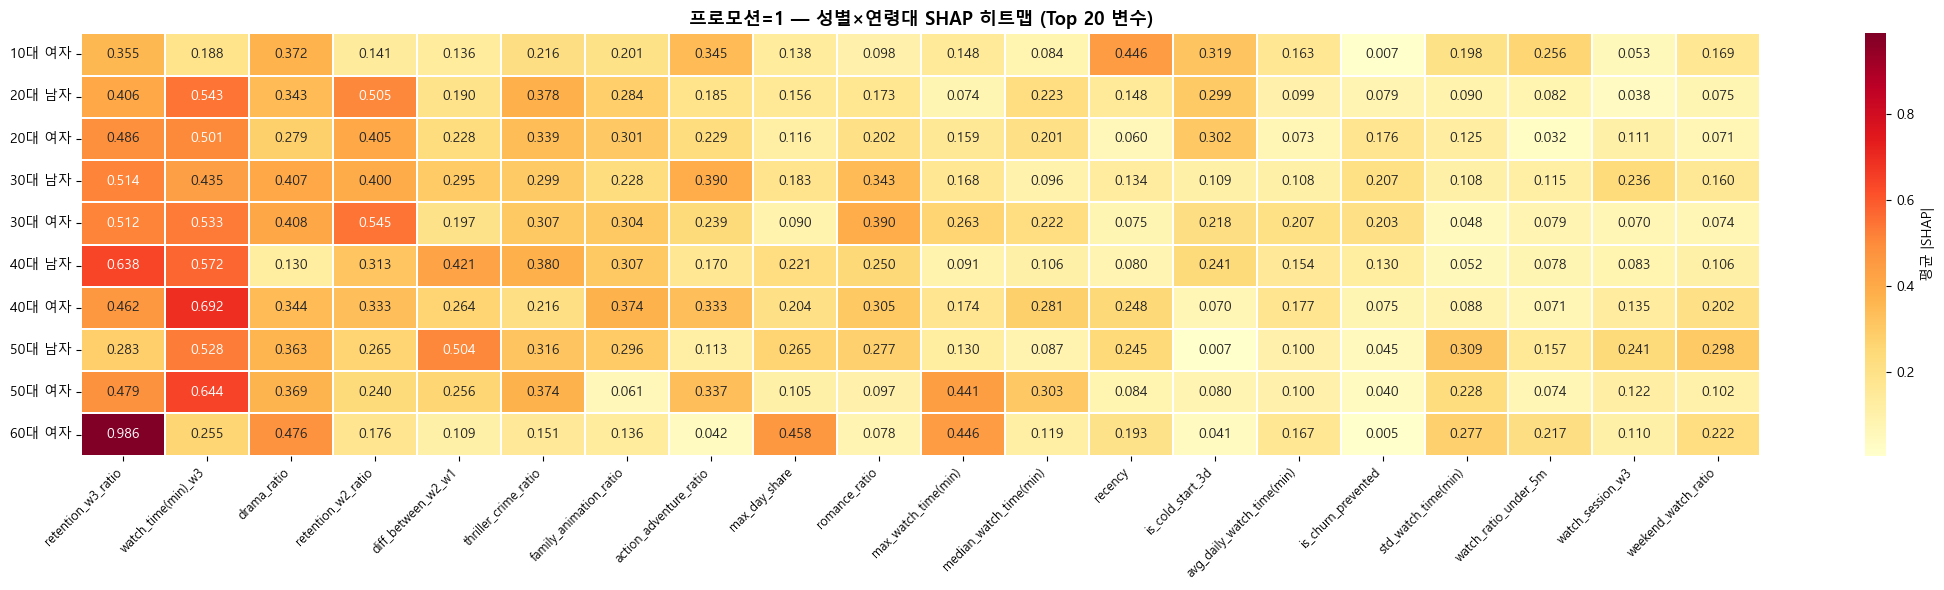

In [9]:
# 전체 Top 20 변수 선정
all_shap_df = pd.DataFrame(shap_results).T
top_vars = all_shap_df.mean().sort_values(ascending=False).head(20).index.tolist()

for plabel in ['프로모션=0', '프로모션=1']:
    # 성별×연령대 교차 그룹만
    cross = [f'{plabel} / {a}대 {g}' for a in AGE_GROUPS
             for g in ['남자','여자']
             if f'{plabel} / {a}대 {g}' in shap_results]
    if not cross:
        continue

    hm = pd.DataFrame({n: shap_results[n][top_vars] for n in cross}).T
    # 행 이름 간소화
    hm.index = [n.replace(f'{plabel} / ', '') for n in cross]

    fig, ax = plt.subplots(figsize=(22, max(6, len(cross)*0.6)))
    sns.heatmap(hm, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.3, ax=ax, cbar_kws={'label': '평균 |SHAP|'})
    ax.set_title(f'{plabel} — 성별×연령대 SHAP 히트맵 (Top 20 변수)',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout(); plt.show()

## 그룹별 Top 10 중요 변수 순위표

In [10]:
# 정렬 순서: prom0 성별 → prom0 연령 → prom0 교차 → prom1 ...
ordered = []
for plabel in ['프로모션=0', '프로모션=1']:
    for g in ['남자','여자']:
        n = f'{plabel} / {g}'
        if n in shap_results: ordered.append(n)
    for a in AGE_GROUPS:
        n = f'{plabel} / {a}대'
        if n in shap_results: ordered.append(n)
    for a in AGE_GROUPS:
        for g in ['남자','여자']:
            n = f'{plabel} / {a}대 {g}'
            if n in shap_results: ordered.append(n)

for name in ordered:
    top10 = shap_results[name].sort_values(ascending=False).head(10)
    print(f'\n[{name}]  AUC={auc_results[name]:.4f}  n={all_subgroups[name].sum():,}명')
    for rank, (var, val) in enumerate(top10.items(), 1):
        print(f'  {rank:2d}. {var:<35} {val:.4f}')


[프로모션=0 / 남자]  AUC=0.8585  n=2,763명
   1. retention_w3_ratio                  0.6176
   2. diff_between_w2_w1                  0.4282
   3. watch_time(min)_w3                  0.4221
   4. drama_ratio                         0.3934
   5. retention_w2_ratio                  0.3551
   6. max_day_share                       0.3017
   7. thriller_crime_ratio                0.2592
   8. romance_ratio                       0.2429
   9. median_watch_time(min)              0.2265
  10. family_animation_ratio              0.2262

[프로모션=0 / 여자]  AUC=0.8719  n=5,058명
   1. watch_time(min)_w3                  0.5928
   2. retention_w3_ratio                  0.5142
   3. drama_ratio                         0.3704
   4. retention_w2_ratio                  0.3644
   5. diff_between_w2_w1                  0.3423
   6. thriller_crime_ratio                0.2958
   7. family_animation_ratio              0.2778
   8. action_adventure_ratio              0.2626
   9. romance_ratio                       0.

---
## 프로모션 0 vs 1 비교 — 동일 인구통계 그룹 내

같은 성별/연령대에서 **프로모션=0과 프로모션=1의 SHAP 중요도 차이**를 비교합니다.
- 양수(+): 프로모션=1에서 더 중요한 변수
- 음수(-): 프로모션=0에서 더 중요한 변수

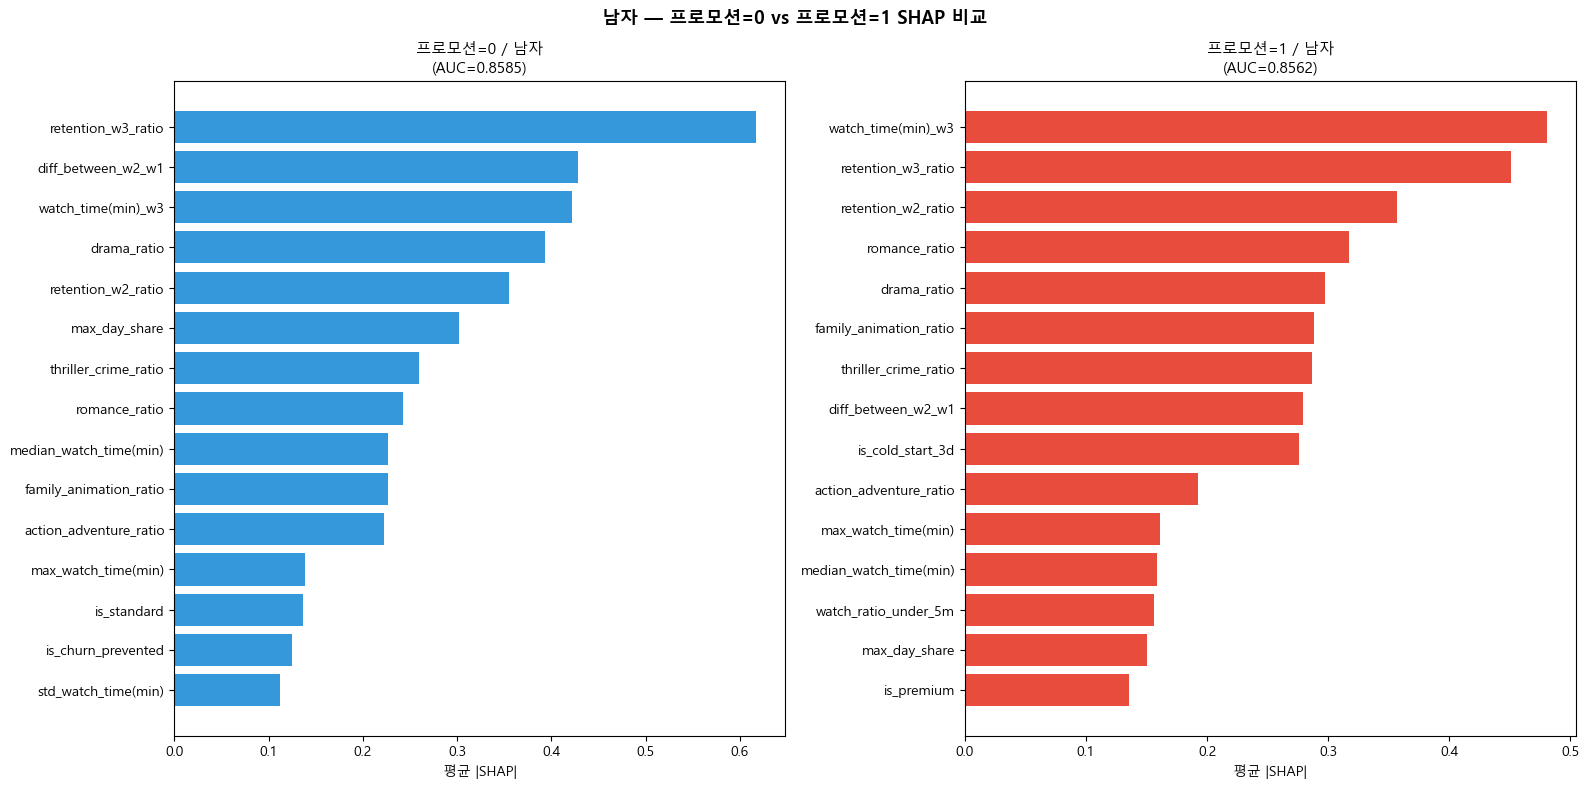


=== 남자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
양수: 프로모션=1에서 더 중요  /  음수: 프로모션=0에서 더 중요

                          프로모션=0    프로모션=1   차이(1-0)
is_cold_start_3d        0.105442  0.275731  0.170289
retention_w3_ratio      0.617561  0.451129 -0.166432
max_day_share           0.301742  0.150440 -0.151302
diff_between_w2_w1      0.428243  0.279431 -0.148811
is_premium              0.009431  0.135836  0.126404
watch_ratio_under_5m    0.051794  0.156220  0.104426
drama_ratio             0.393433  0.297294 -0.096139
romance_ratio           0.242940  0.317077  0.074138
old_movie_ratio(5y)     0.111657  0.041062 -0.070595
median_watch_time(min)  0.226472  0.159044 -0.067428
std_watch_time(min)     0.111874  0.047689 -0.064185
is_standard             0.136768  0.074322 -0.062446
family_animation_ratio  0.226234  0.288014  0.061779
watch_time(min)_w3      0.422057  0.480466  0.058409
weekend_watch_ratio     0.088807  0.035874 -0.052933


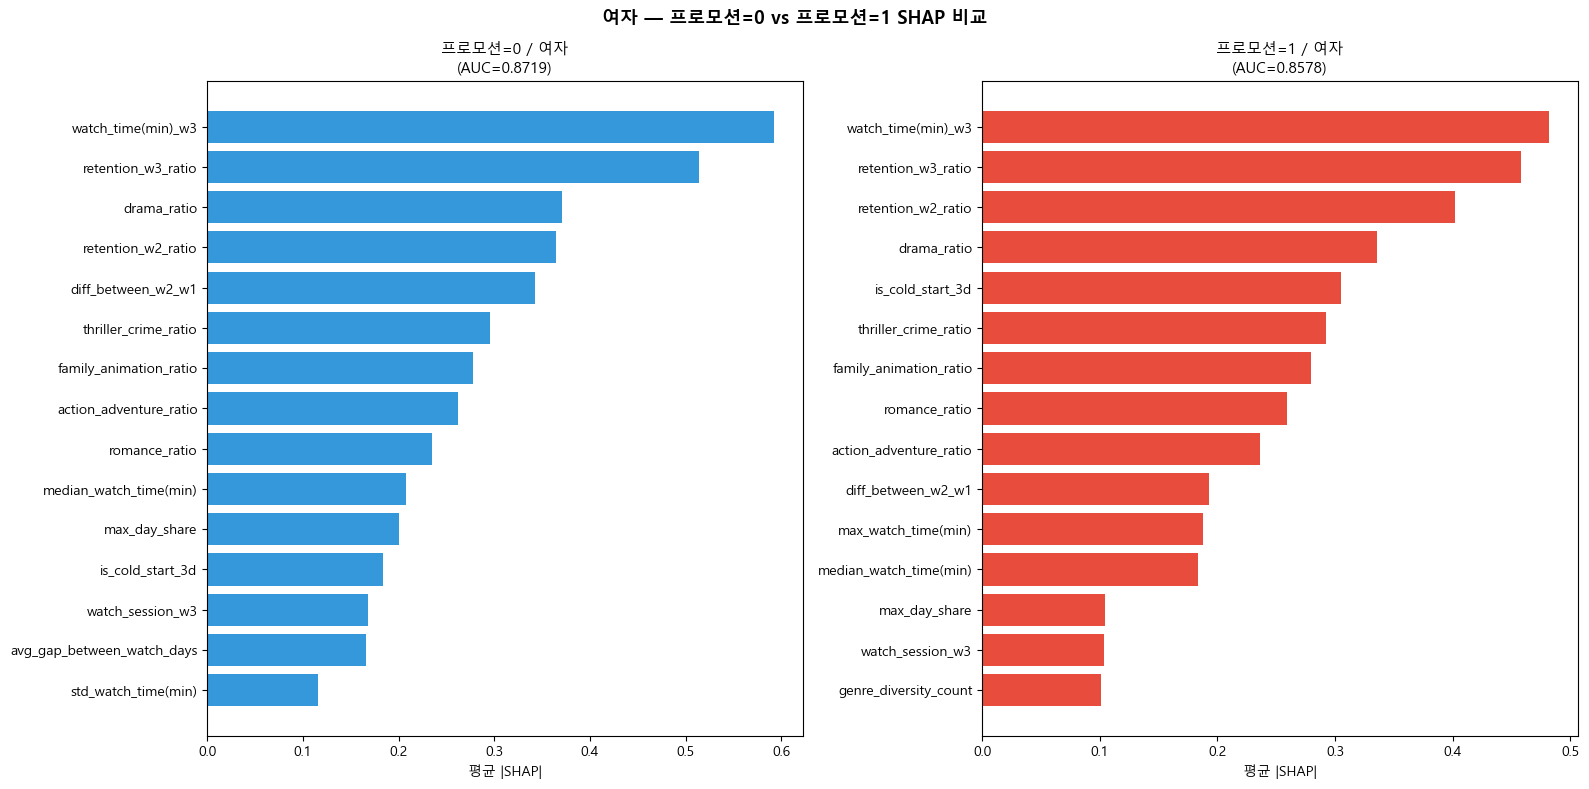


=== 여자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
양수: 프로모션=1에서 더 중요  /  음수: 프로모션=0에서 더 중요

                              프로모션=0    프로모션=1   차이(1-0)
diff_between_w2_w1          0.342279  0.193003 -0.149276
avg_gap_between_watch_days  0.165932  0.033472 -0.132460
max_watch_time(min)         0.063027  0.187342  0.124315
is_cold_start_3d            0.183952  0.305145  0.121193
watch_time(min)_w3          0.592768  0.482007 -0.110761
max_day_share               0.200295  0.104489 -0.095806
watch_session_w3            0.168296  0.103340 -0.064956
reg_is_weekend              0.073399  0.008877 -0.064522
unique_movie                0.033397  0.090943  0.057546
retention_w3_ratio          0.514208  0.457865 -0.056343
is_premium                  0.021849  0.077301  0.055452
std_watch_time(min)         0.115705  0.069847 -0.045858
payment_is_ios              0.042062  0.000000 -0.042062
retention_w2_ratio          0.364419  0.402039  0.037621
is_w1_over_50pct            0.046834  0.010134 -0.036700



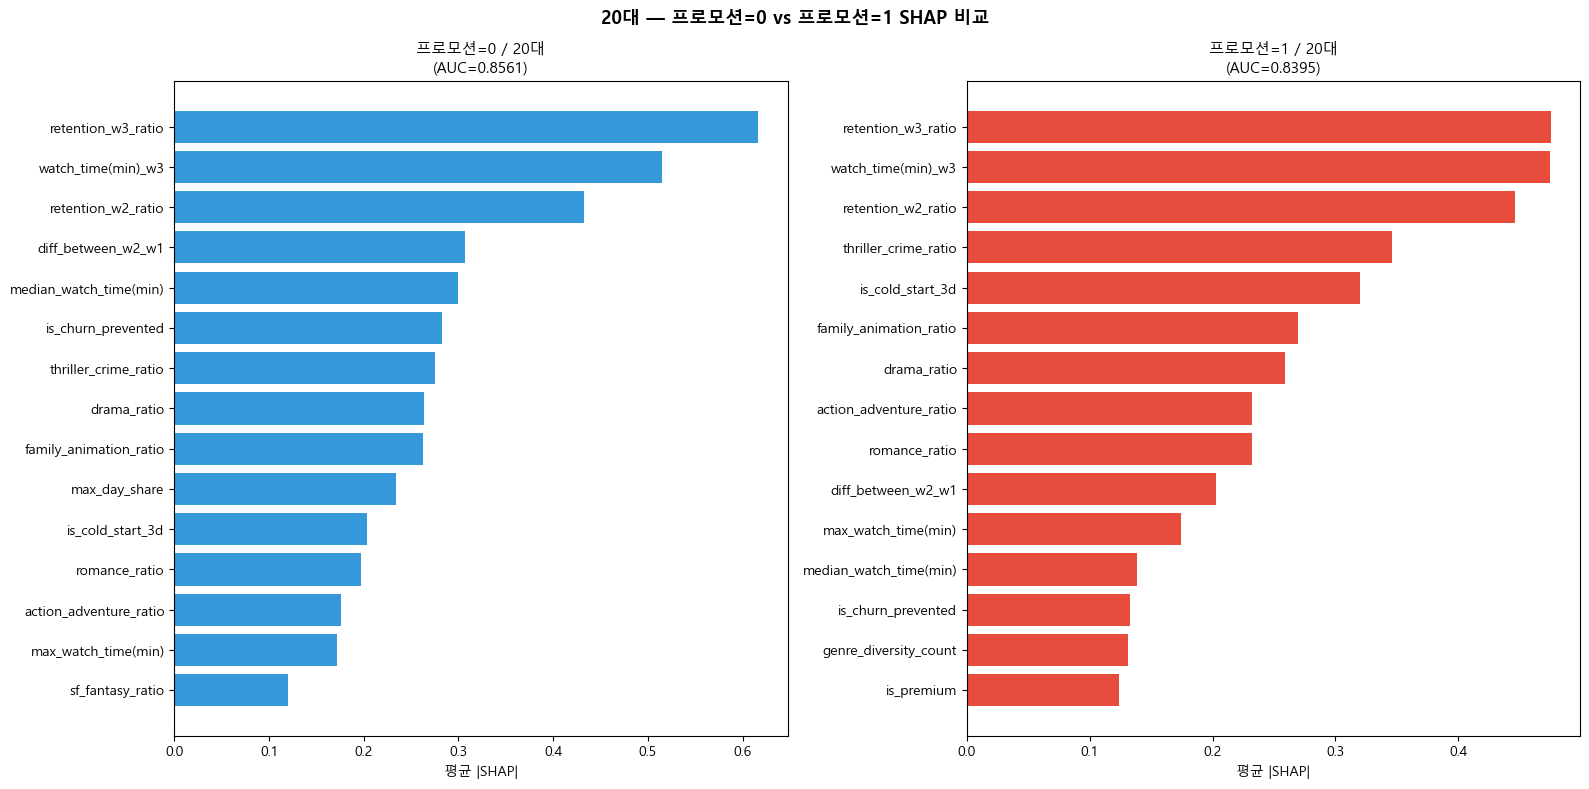


=== 20대: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                             프로모션=0    프로모션=1   차이(1-0)
median_watch_time(min)     0.299813  0.138511 -0.161302
is_churn_prevented         0.282521  0.132757 -0.149765
retention_w3_ratio         0.616533  0.475251 -0.141281
max_day_share              0.234187  0.109154 -0.125033
is_cold_start_3d           0.203351  0.319883  0.116532
diff_between_w2_w1         0.307200  0.202875 -0.104325
genre_diversity_count      0.032129  0.131231  0.099102
is_premium                 0.027120  0.123656  0.096537
payment_is_ios             0.075630  0.000000 -0.075630
avg_daily_watch_time(min)  0.112140  0.039788 -0.072352
watch_ratio_under_1m       0.092032  0.020521 -0.071511
thriller_crime_ratio       0.275621  0.346270  0.070649
avg_gap_w3_watch_days      0.092357  0.034993 -0.057363
action_adventure_ratio     0.176452  0.231822  0.055370
sf_fantasy_ratio           0.120047  0.067388 -0.052660


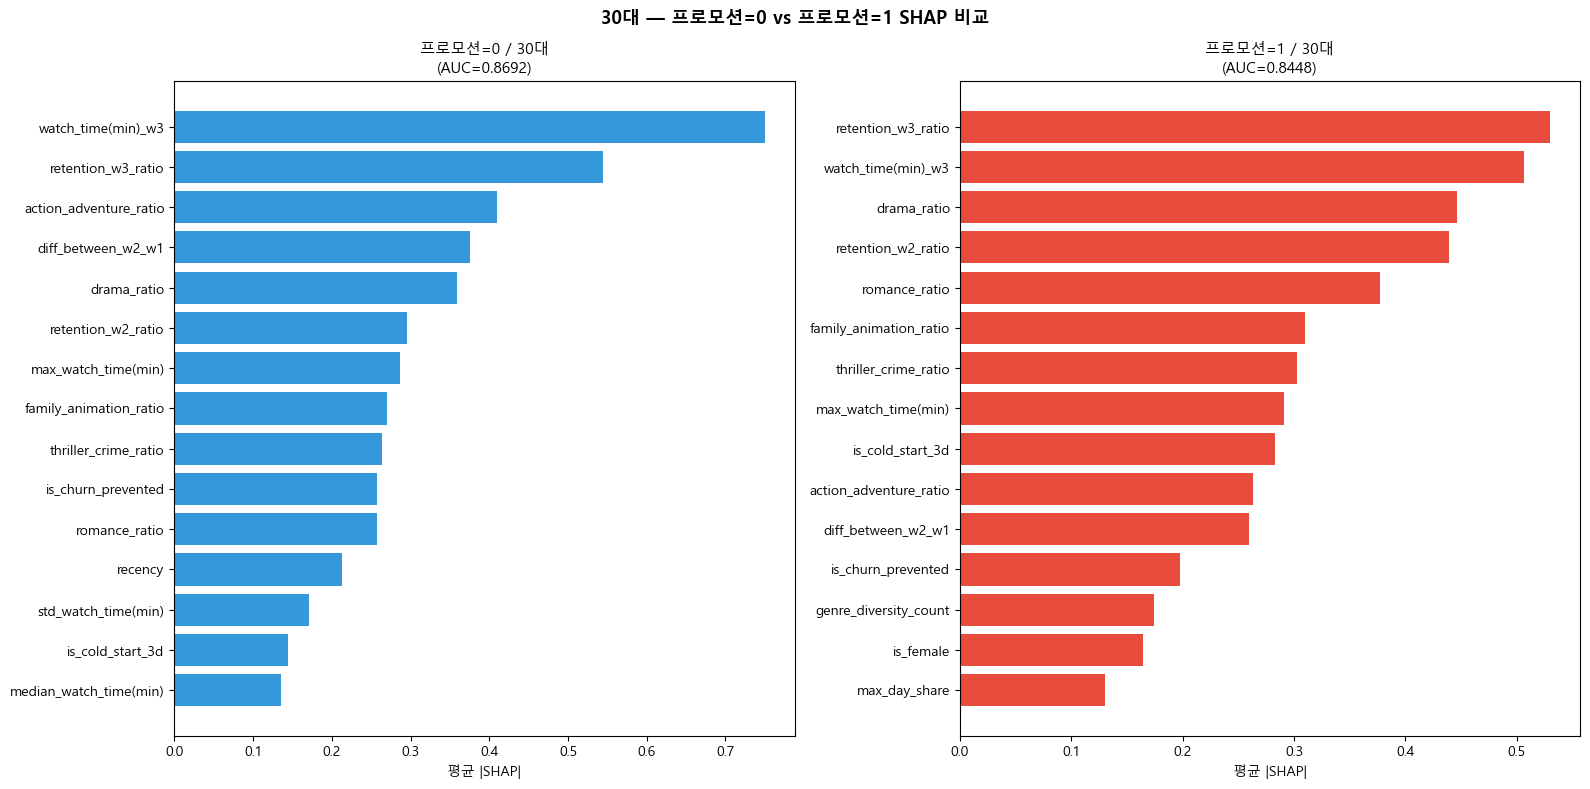


=== 30대: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                          프로모션=0    프로모션=1   차이(1-0)
watch_time(min)_w3      0.750147  0.506136 -0.244011
action_adventure_ratio  0.409823  0.263496 -0.146327
is_female               0.018522  0.164239  0.145717
retention_w2_ratio      0.296083  0.438864  0.142780
is_cold_start_3d        0.144553  0.282787  0.138234
recency                 0.212382  0.078736 -0.133646
romance_ratio           0.257052  0.377112  0.120060
diff_between_w2_w1      0.375449  0.259548 -0.115901
is_premium              0.005417  0.116383  0.110966
std_watch_time(min)     0.171327  0.077162 -0.094165
reg_is_weekend          0.100824  0.013887 -0.086937
drama_ratio             0.359498  0.446296  0.086799
payment_is_mobile       0.001808  0.068257  0.066449
watch_session_w3        0.045842  0.108936  0.063094
genre_diversity_count   0.114227  0.174090  0.059864


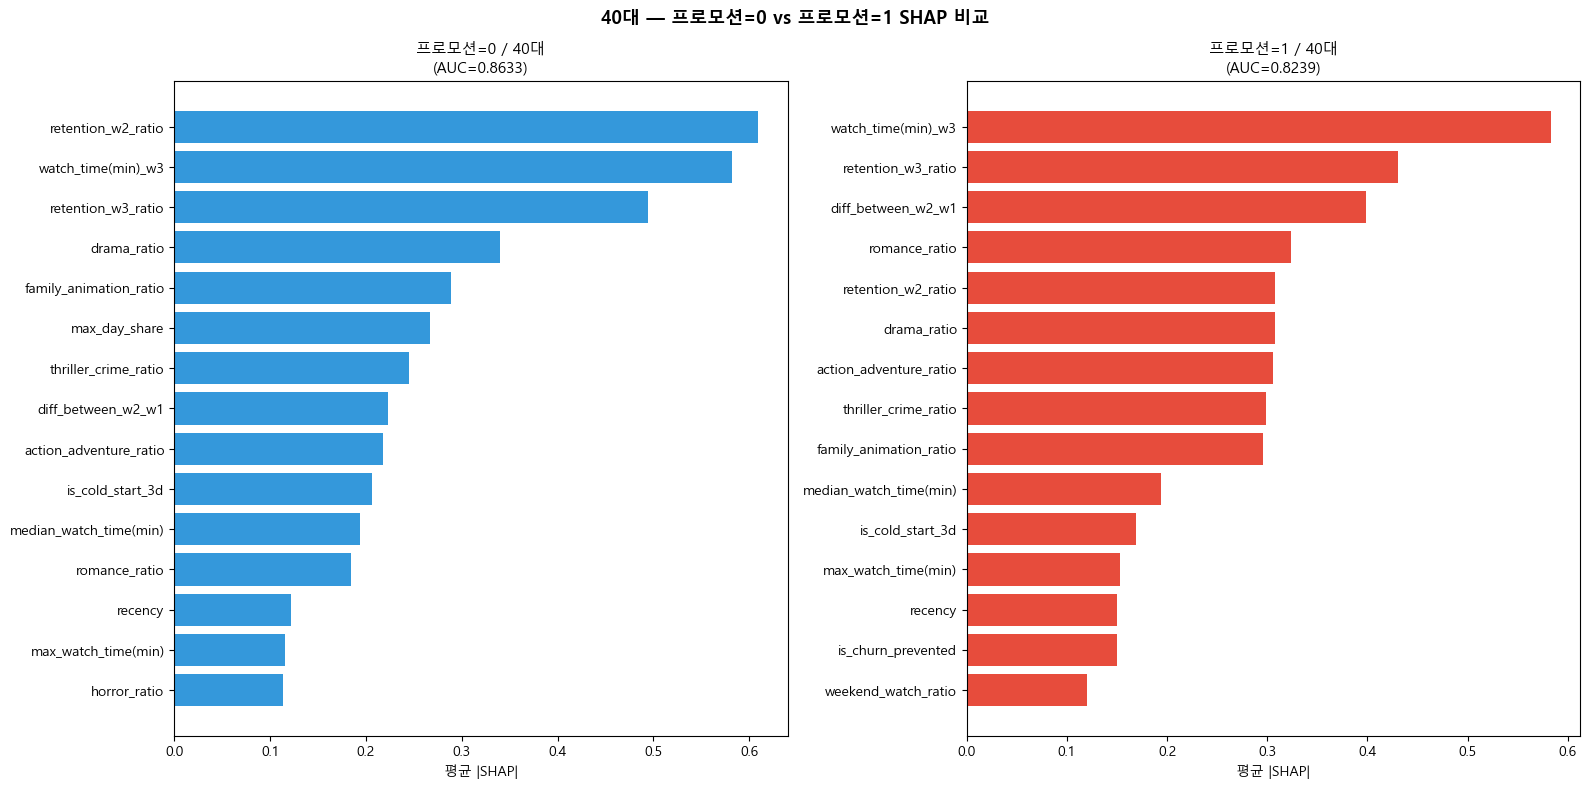


=== 40대: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                          프로모션=0    프로모션=1   차이(1-0)
retention_w2_ratio      0.609493  0.307992 -0.301500
diff_between_w2_w1      0.223470  0.398572  0.175102
max_day_share           0.267128  0.106217 -0.160911
romance_ratio           0.184257  0.323995  0.139738
horror_ratio            0.113257  0.016035 -0.097222
action_adventure_ratio  0.217264  0.305910  0.088646
is_churn_prevented      0.066508  0.149589  0.083081
watch_session_w1        0.037516  0.116590  0.079074
retention_w3_ratio      0.494654  0.430265 -0.064389
avg_gap_w3_watch_days   0.079640  0.019897 -0.059742
payment_is_pc           0.008340  0.066289  0.057950
thriller_crime_ratio    0.244755  0.299019  0.054264
payment_is_ios          0.052297  0.000000 -0.052297
std_watch_time(min)     0.103979  0.055321 -0.048658
unique_movie            0.027612  0.075029  0.047417


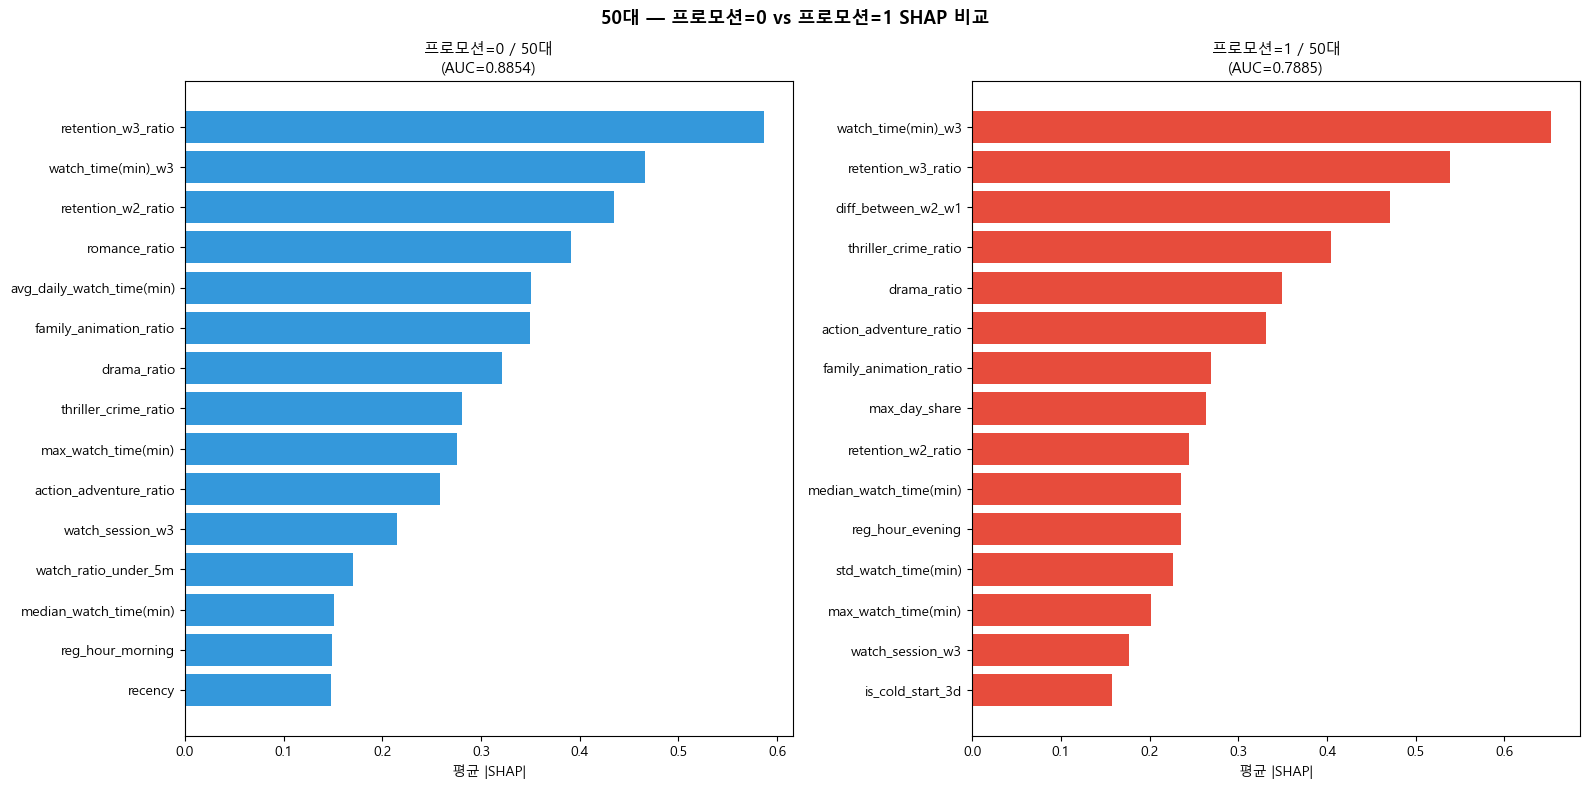


=== 50대: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                             프로모션=0    프로모션=1   차이(1-0)
diff_between_w2_w1         0.108528  0.471058  0.362531
avg_daily_watch_time(min)  0.350264  0.058764 -0.291500
romance_ratio              0.391199  0.119417 -0.271783
retention_w2_ratio         0.434355  0.244395 -0.189959
watch_time(min)_w3         0.466455  0.652541  0.186085
reg_hour_evening           0.058750  0.235083  0.176333
is_premium                 0.000000  0.148691  0.148691
max_day_share              0.124827  0.263989  0.139162
std_watch_time(min)        0.090393  0.226679  0.136287
thriller_crime_ratio       0.280280  0.404741  0.124461
reg_hour_morning           0.148660  0.044999 -0.103661
watch_ratio_under_5m       0.170248  0.072494 -0.097753
sf_fantasy_ratio           0.018103  0.115509  0.097407
new_movie_in_90d_ratio     0.137245  0.041118 -0.096126
max_daily_sessions         0.131247  0.035516 -0.095732


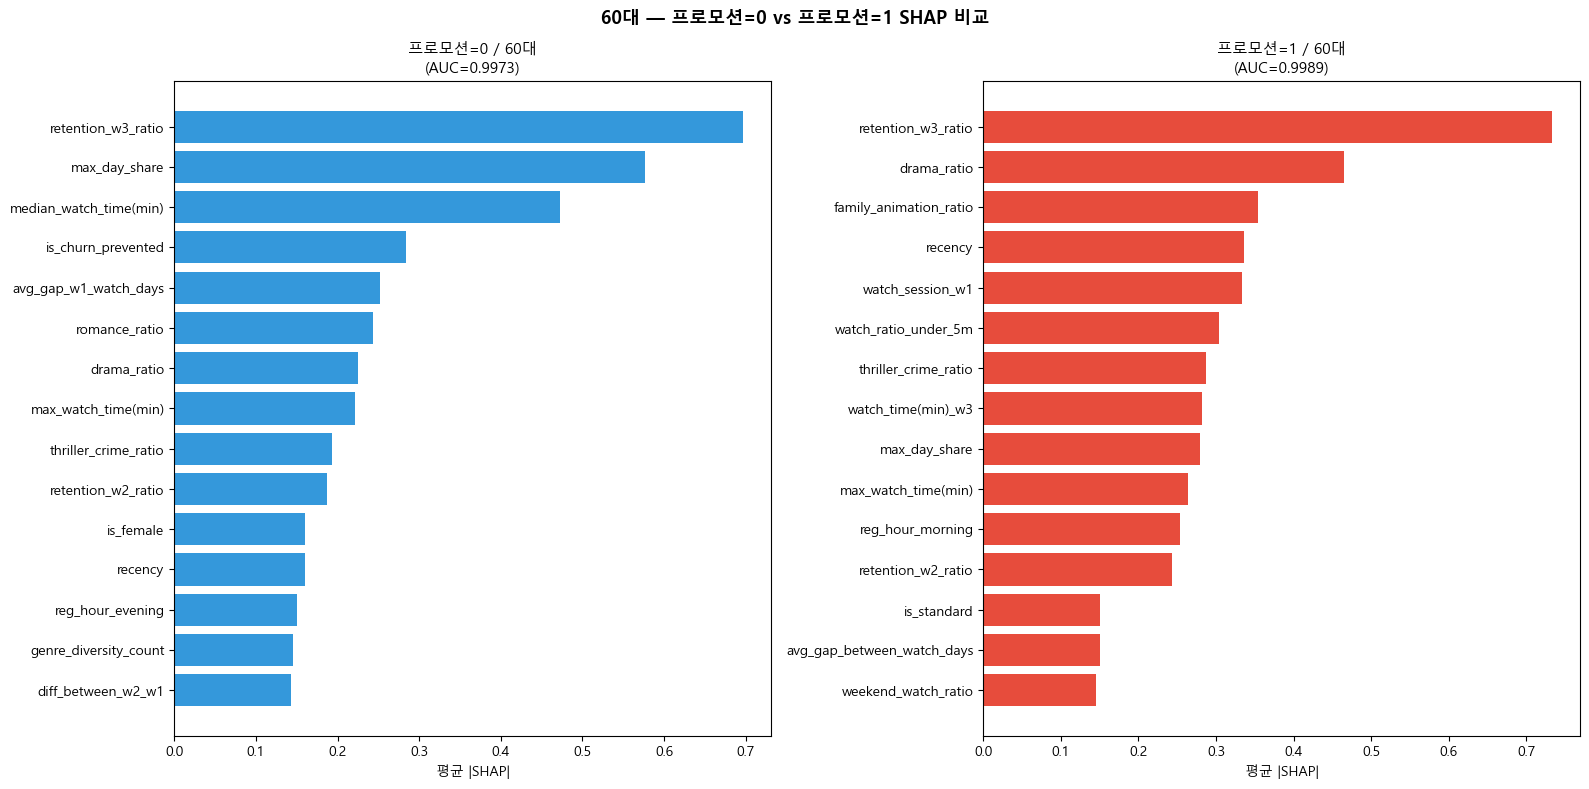


=== 60대: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                          프로모션=0    프로모션=1   차이(1-0)
median_watch_time(min)  0.472575  0.124490 -0.348085
max_day_share           0.577115  0.278747 -0.298367
is_churn_prevented      0.283522  0.015642 -0.267880
watch_ratio_under_5m    0.059289  0.304028  0.244739
drama_ratio             0.224532  0.464694  0.240162
family_animation_ratio  0.118523  0.354657  0.236135
reg_hour_morning        0.021286  0.254020  0.232734
watch_time(min)_w3      0.049851  0.281768  0.231918
watch_session_w1        0.111637  0.333737  0.222100
avg_gap_w1_watch_days   0.252369  0.030839 -0.221531
recency                 0.160038  0.335612  0.175574
romance_ratio           0.243634  0.110254 -0.133379
is_premium              0.000000  0.128182  0.128182
is_standard             0.034942  0.150305  0.115364
reg_hour_evening        0.150820  0.038069 -0.112751


In [11]:
# ── 성별별 프로모션 0 vs 1 비교 ──────────────────────────────────────────────
for glabel in ['남자', '여자']:
    n0 = f'프로모션=0 / {glabel}'
    n1 = f'프로모션=1 / {glabel}'
    if n0 not in shap_results or n1 not in shap_results:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, name, color in zip(axes, [n0, n1], ['#3498db', '#e74c3c']):
        top = shap_results[name].sort_values().tail(15)
        ax.barh(top.index, top.values, color=color)
        ax.set_title(f'{name}\n(AUC={auc_results[name]:.4f})', fontsize=11)
        ax.set_xlabel('평균 |SHAP|')
    plt.suptitle(f'{glabel} — 프로모션=0 vs 프로모션=1 SHAP 비교', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    comp = pd.DataFrame({'프로모션=0': shap_results[n0], '프로모션=1': shap_results[n1]})
    comp['차이(1-0)'] = comp['프로모션=1'] - comp['프로모션=0']
    comp = comp.sort_values('차이(1-0)', key=abs, ascending=False)
    print(f'\n=== {glabel}: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===')
    print('양수: 프로모션=1에서 더 중요  /  음수: 프로모션=0에서 더 중요\n')
    print(comp.head(15).to_string())

# ── 연령대별 프로모션 0 vs 1 비교 ────────────────────────────────────────────
print('\n' + '='*70)
for age in AGE_GROUPS:
    n0 = f'프로모션=0 / {age}대'
    n1 = f'프로모션=1 / {age}대'
    if n0 not in shap_results or n1 not in shap_results:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, name, color in zip(axes, [n0, n1], ['#3498db', '#e74c3c']):
        top = shap_results[name].sort_values().tail(15)
        ax.barh(top.index, top.values, color=color)
        ax.set_title(f'{name}\n(AUC={auc_results[name]:.4f})', fontsize=11)
        ax.set_xlabel('평균 |SHAP|')
    plt.suptitle(f'{age}대 — 프로모션=0 vs 프로모션=1 SHAP 비교', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    comp = pd.DataFrame({'프로모션=0': shap_results[n0], '프로모션=1': shap_results[n1]})
    comp['차이(1-0)'] = comp['프로모션=1'] - comp['프로모션=0']
    comp = comp.sort_values('차이(1-0)', key=abs, ascending=False)
    print(f'\n=== {age}대: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===')
    print(comp.head(15).to_string())

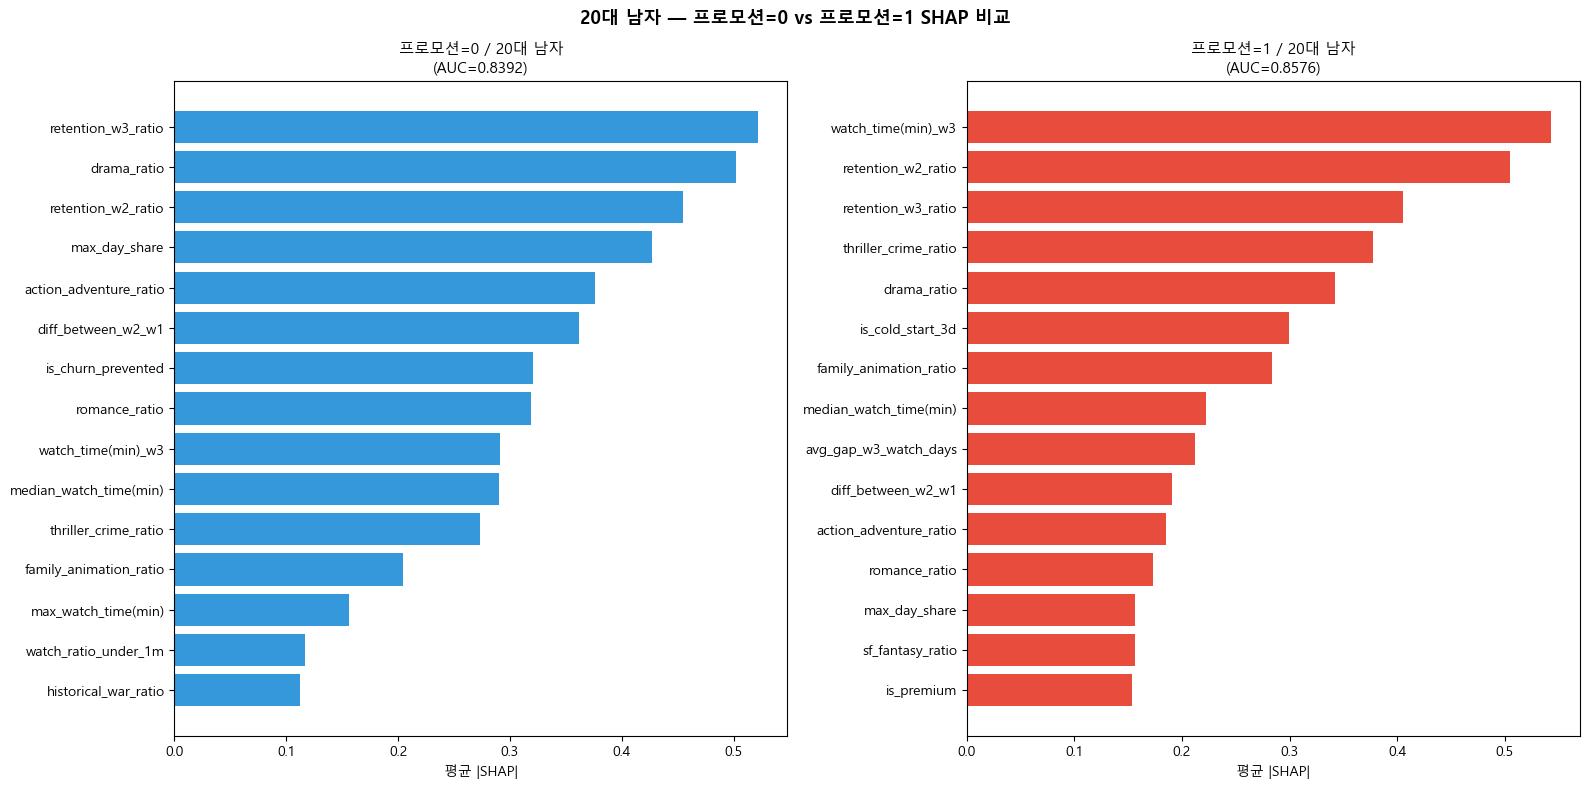


=== 20대 남자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                          프로모션=0    프로모션=1   차이(1-0)
max_day_share           0.427485  0.156330 -0.271155
watch_time(min)_w3      0.290902  0.542860  0.251958
is_churn_prevented      0.320593  0.079478 -0.241115
is_cold_start_3d        0.067961  0.299226  0.231265
action_adventure_ratio  0.376481  0.185429 -0.191052
avg_gap_w3_watch_days   0.027737  0.212026  0.184290
diff_between_w2_w1      0.362249  0.190440 -0.171809
drama_ratio             0.502573  0.342690 -0.159883
romance_ratio           0.319241  0.172694 -0.146547
is_premium              0.008750  0.153295  0.144545
retention_w3_ratio      0.522149  0.405581 -0.116568
thriller_crime_ratio    0.273652  0.377749  0.104097
recency                 0.058847  0.148451  0.089603
payment_is_ios          0.084392  0.000000 -0.084392
sf_fantasy_ratio        0.073022  0.156252  0.083231


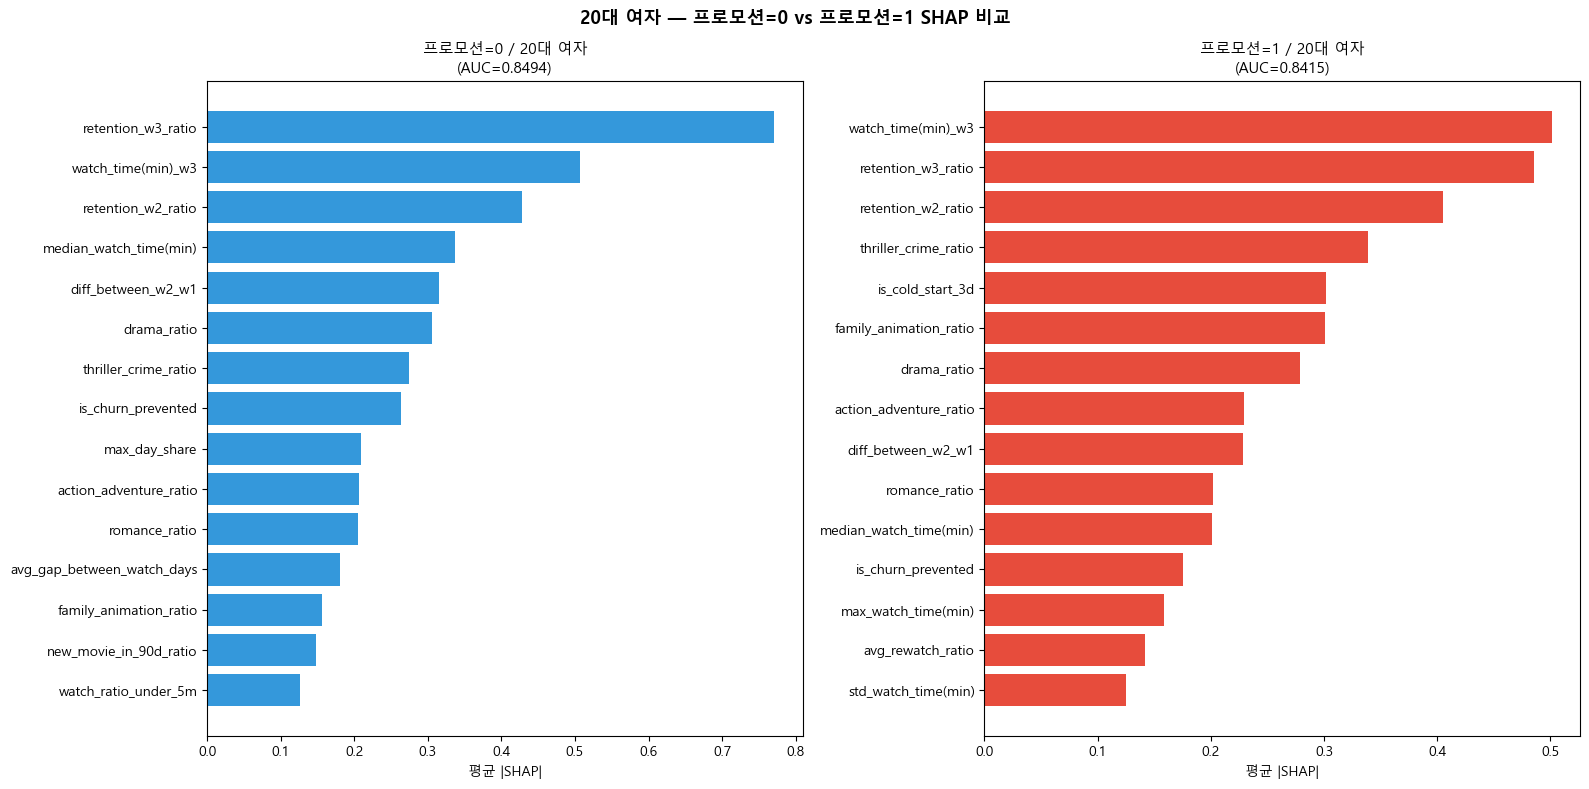


=== 20대 여자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                              프로모션=0    프로모션=1   차이(1-0)
retention_w3_ratio          0.771158  0.485551 -0.285607
is_cold_start_3d            0.082838  0.301845  0.219007
family_animation_ratio      0.156150  0.301046  0.144896
median_watch_time(min)      0.336758  0.200826 -0.135932
avg_gap_between_watch_days  0.180520  0.068497 -0.112024
new_movie_in_90d_ratio      0.148030  0.048757 -0.099272
avg_gap_w3_watch_days       0.113192  0.014420 -0.098772
watch_ratio_under_5m        0.126055  0.031853 -0.094202
max_day_share               0.208723  0.115914 -0.092808
is_churn_prevented          0.263606  0.175741 -0.087865
diff_between_w2_w1          0.315776  0.228444 -0.087333
is_premium                  0.038843  0.118465  0.079622
avg_rewatch_ratio           0.073144  0.142209  0.069064
thriller_crime_ratio        0.274379  0.339114  0.064735
max_watch_time(min)         0.096556  0.158823  0.062267


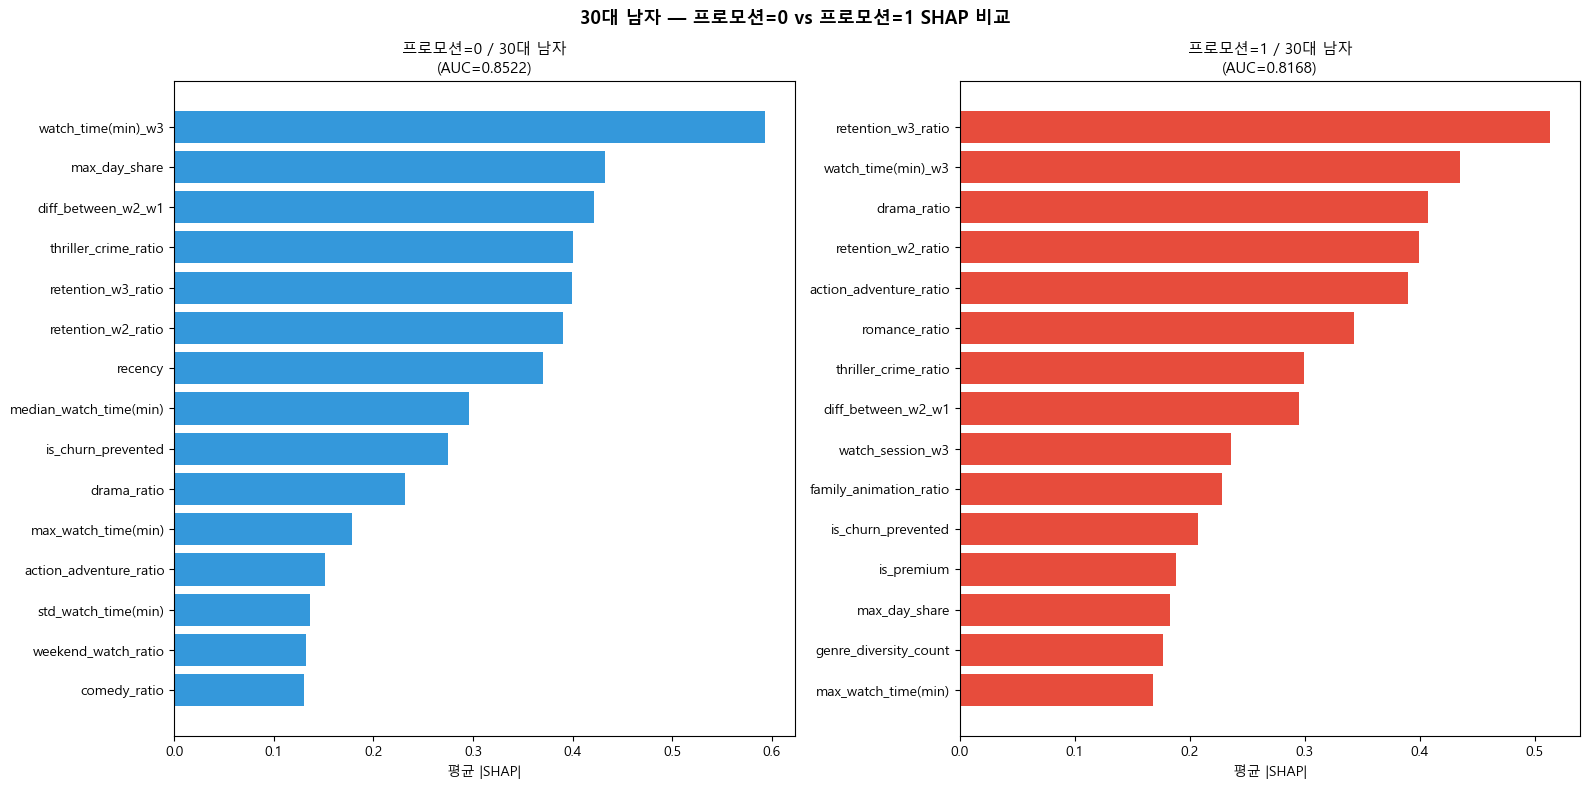


=== 30대 남자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                          프로모션=0    프로모션=1   차이(1-0)
max_day_share           0.432347  0.183046 -0.249301
action_adventure_ratio  0.151794  0.389615  0.237822
recency                 0.369866  0.133507 -0.236359
romance_ratio           0.114048  0.343141  0.229093
median_watch_time(min)  0.296046  0.096252 -0.199793
watch_session_w3        0.040332  0.235635  0.195303
drama_ratio             0.231224  0.407287  0.176063
watch_time(min)_w3      0.593167  0.435368 -0.157799
family_animation_ratio  0.077150  0.228221  0.151071
genre_diversity_count   0.044580  0.176702  0.132122
diff_between_w2_w1      0.421334  0.295015 -0.126319
retention_w3_ratio      0.399618  0.513699  0.114080
is_premium              0.076357  0.188276  0.111920
thriller_crime_ratio    0.399910  0.299488 -0.100422
is_cold_start_3d        0.024991  0.109301  0.084310


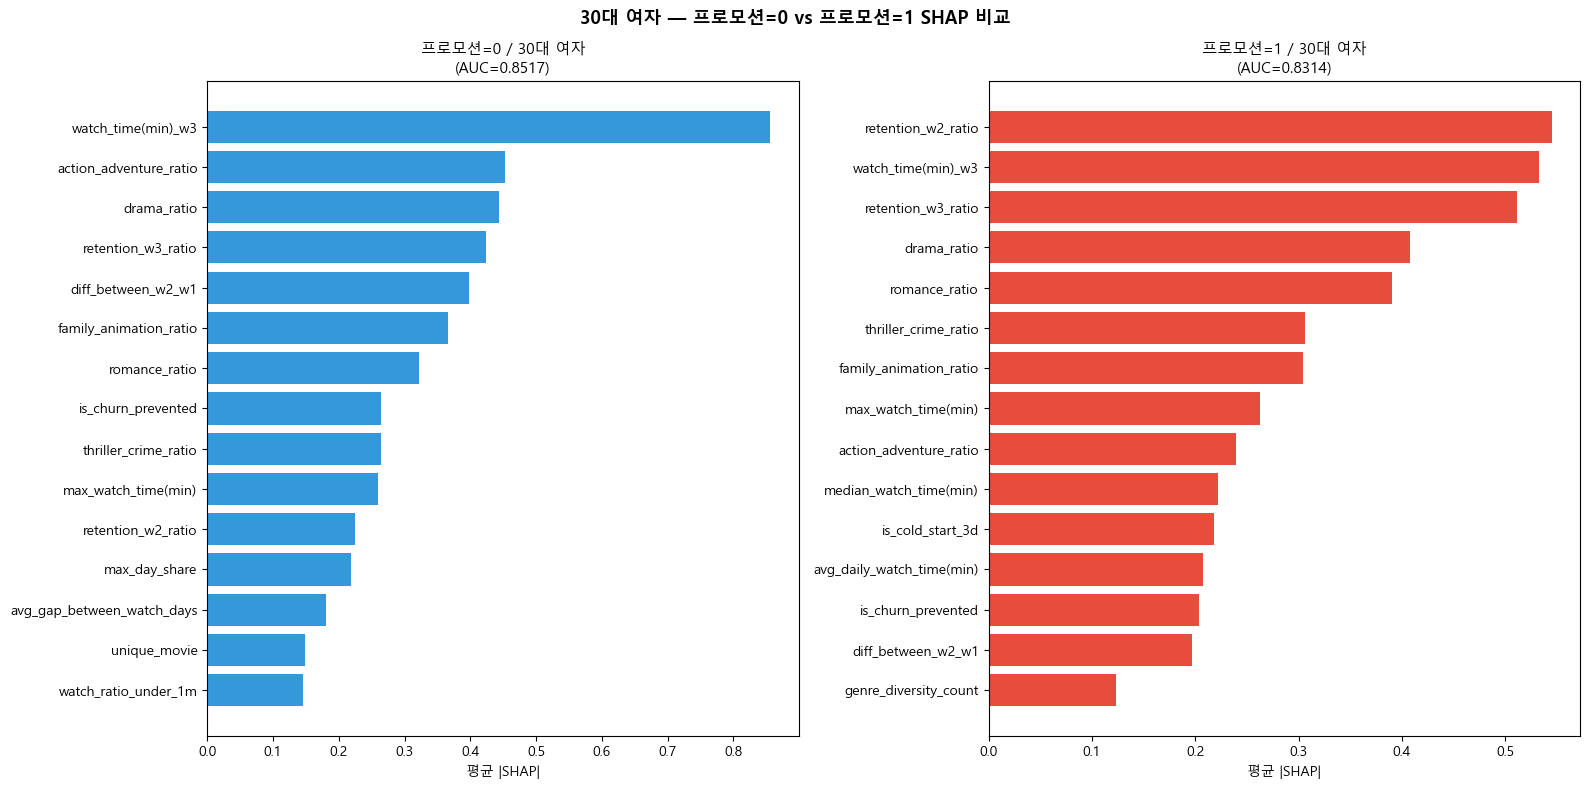


=== 30대 여자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                              프로모션=0    프로모션=1   차이(1-0)
watch_time(min)_w3          0.856478  0.532639 -0.323839
retention_w2_ratio          0.224403  0.545126  0.320723
action_adventure_ratio      0.453378  0.239244 -0.214134
diff_between_w2_w1          0.397518  0.196586 -0.200932
is_cold_start_3d            0.051511  0.217927  0.166416
max_day_share               0.218345  0.090302 -0.128043
median_watch_time(min)      0.116696  0.221773  0.105077
avg_gap_between_watch_days  0.180076  0.080510 -0.099567
sf_fantasy_ratio            0.115096  0.025422 -0.089674
retention_w3_ratio          0.424512  0.511832  0.087319
avg_daily_watch_time(min)   0.122779  0.207256  0.084477
payment_is_mobile           0.005932  0.082499  0.076568
romance_ratio               0.321721  0.390113  0.068392
watch_ratio_under_1m        0.145178  0.082165 -0.063013
family_animation_ratio      0.366687  0.304351 -0.062336


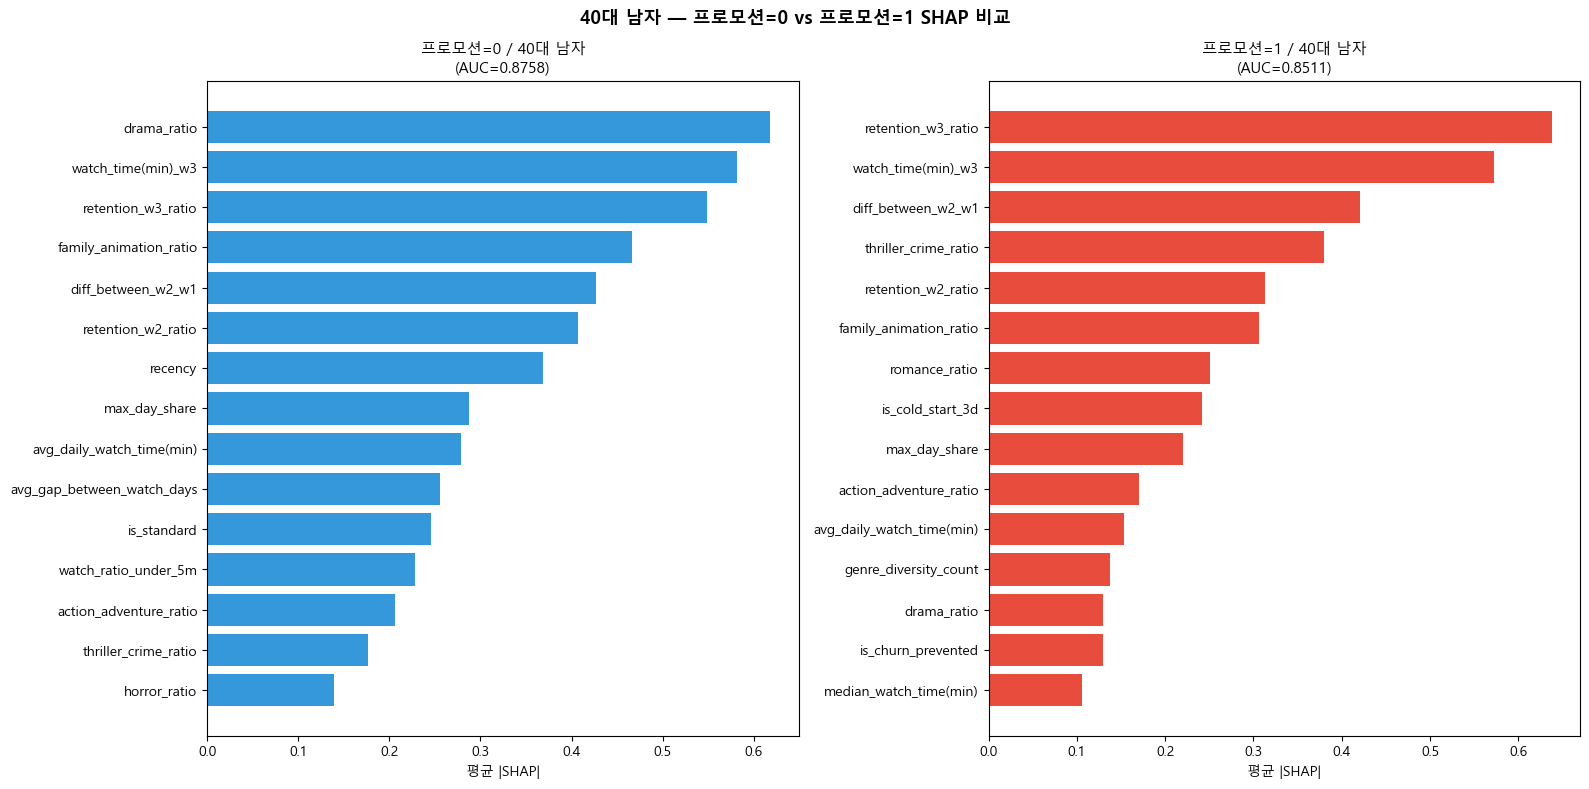


=== 40대 남자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                              프로모션=0    프로모션=1   차이(1-0)
drama_ratio                 0.618415  0.130047 -0.488368
recency                     0.368861  0.080139 -0.288722
thriller_crime_ratio        0.176102  0.379880  0.203778
is_standard                 0.246097  0.072658 -0.173438
family_animation_ratio      0.465950  0.306680 -0.159270
avg_gap_between_watch_days  0.255331  0.099730 -0.155601
watch_ratio_under_5m        0.228613  0.077929 -0.150684
is_cold_start_3d            0.096646  0.241325  0.144679
romance_ratio               0.114196  0.250432  0.136236
avg_daily_watch_time(min)   0.278472  0.153736 -0.124736
retention_w2_ratio          0.406719  0.313486 -0.093233
retention_w3_ratio          0.549051  0.637973  0.088922
genre_diversity_count       0.049848  0.137057  0.087209
horror_ratio                0.139285  0.054950 -0.084334
is_user_verified            0.083896  0.000000 -0.083896


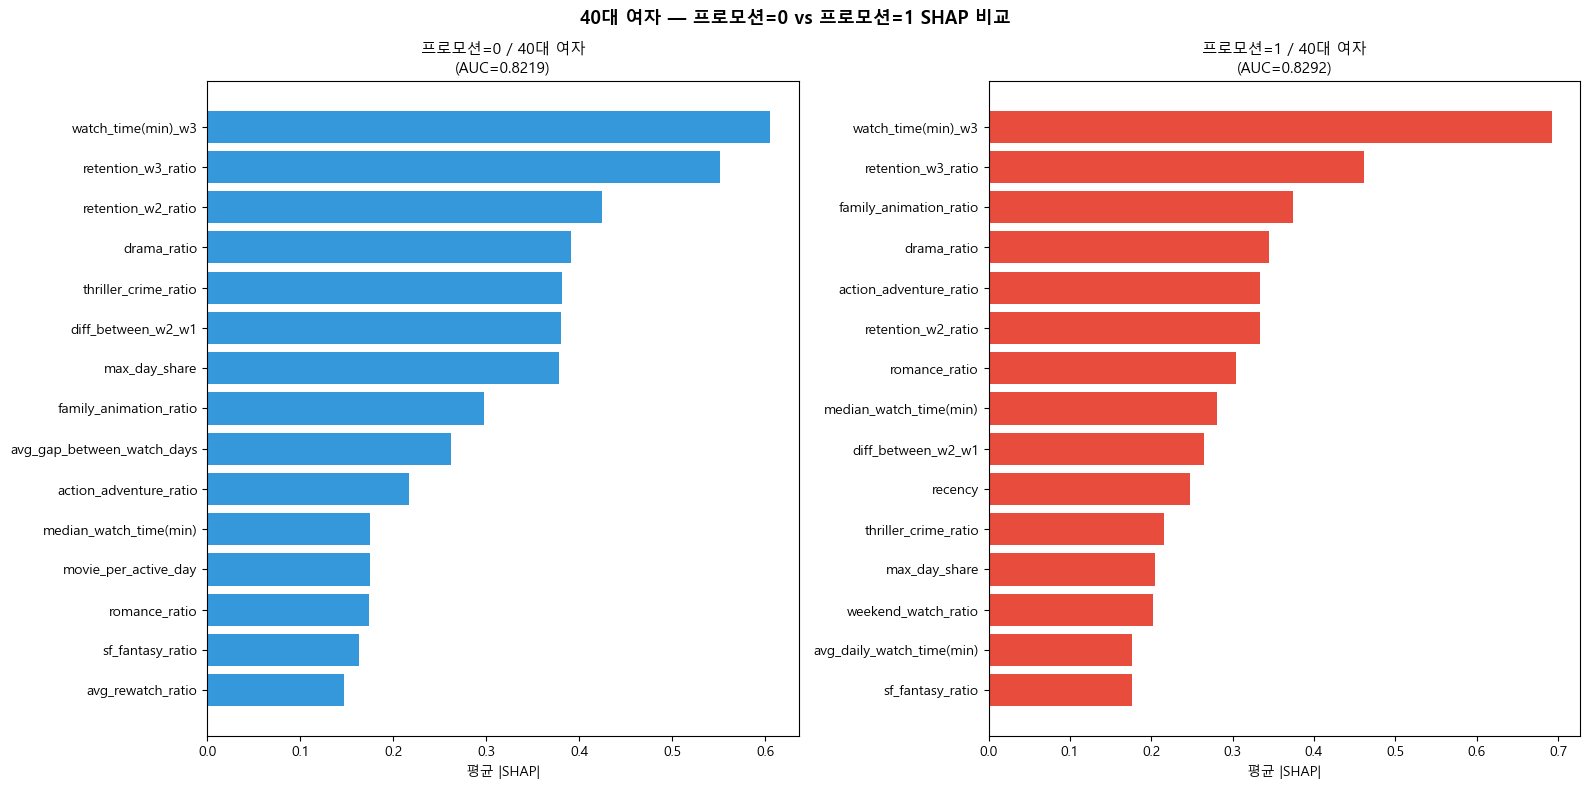


=== 40대 여자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                              프로모션=0    프로모션=1   차이(1-0)
avg_gap_between_watch_days  0.262282  0.069762 -0.192519
recency                     0.068854  0.247751  0.178897
max_day_share               0.378106  0.204007 -0.174099
thriller_crime_ratio        0.381627  0.215866 -0.165761
romance_ratio               0.174396  0.304662  0.130265
diff_between_w2_w1          0.380955  0.264375 -0.116580
action_adventure_ratio      0.217359  0.333244  0.115885
reg_is_weekend              0.132396  0.023692 -0.108704
median_watch_time(min)      0.175553  0.281050  0.105497
avg_rewatch_ratio           0.147394  0.053076 -0.094318
weekend_watch_ratio         0.108898  0.201617  0.092719
retention_w2_ratio          0.424574  0.333026 -0.091548
retention_w3_ratio          0.551150  0.461993 -0.089157
watch_time(min)_w3          0.605731  0.692403  0.086672
avg_daily_watch_time(min)   0.094390  0.176660  0.082270


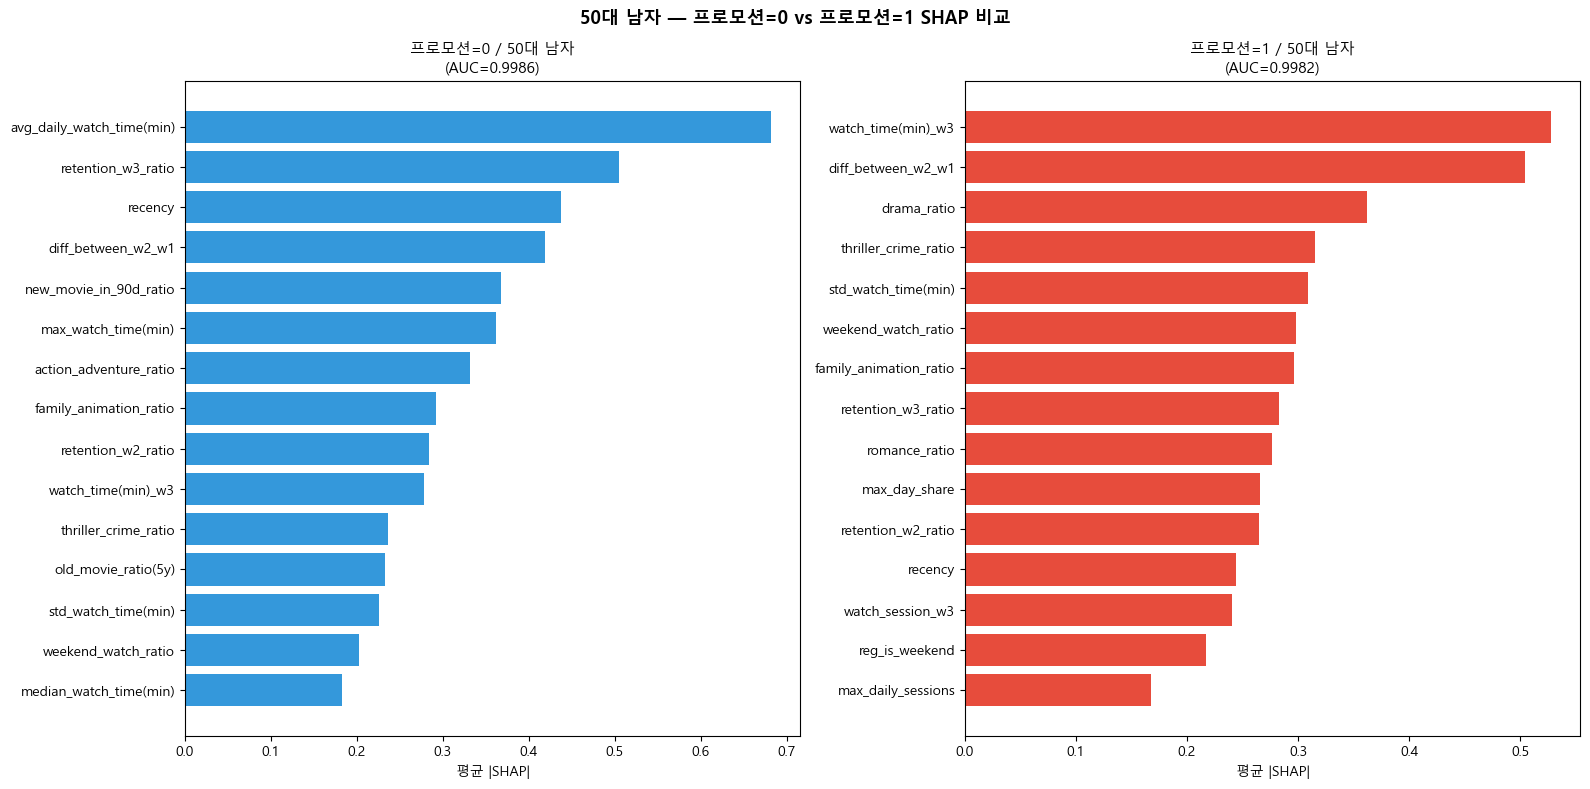


=== 50대 남자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                             프로모션=0    프로모션=1   차이(1-0)
avg_daily_watch_time(min)  0.681122  0.100084 -0.581038
romance_ratio              0.015758  0.276658  0.260900
watch_time(min)_w3         0.278423  0.527634  0.249212
watch_session_w3           0.005429  0.240676  0.235247
max_watch_time(min)        0.361989  0.129661 -0.232328
new_movie_in_90d_ratio     0.367491  0.142936 -0.224555
retention_w3_ratio         0.505074  0.282975 -0.222099
action_adventure_ratio     0.331078  0.112848 -0.218230
drama_ratio                0.150731  0.362580  0.211849
recency                    0.437040  0.244528 -0.192511
max_day_share              0.085339  0.265422  0.180083
max_daily_sessions         0.015935  0.167760  0.151825
reg_is_weekend             0.080026  0.217059  0.137033
comedy_ratio               0.163151  0.034535 -0.128617
reg_hour_night             0.000000  0.127805  0.127805


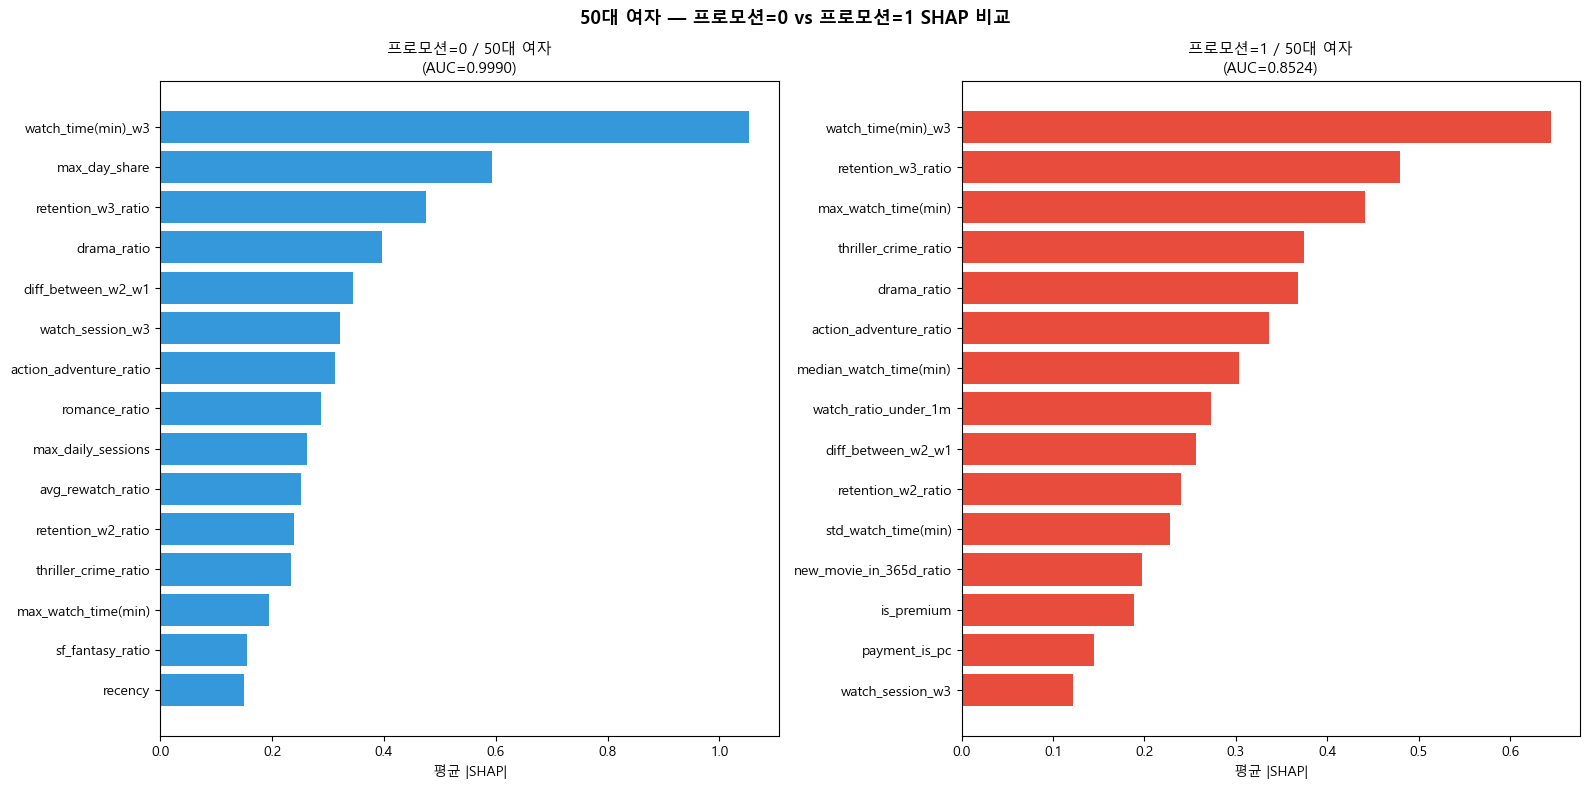


=== 50대 여자: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===
                           프로모션=0    프로모션=1   차이(1-0)
max_day_share            0.592944  0.105230 -0.487713
watch_time(min)_w3       1.053575  0.644318 -0.409256
median_watch_time(min)   0.044291  0.303238  0.258948
max_watch_time(min)      0.194053  0.441490  0.247437
avg_rewatch_ratio        0.250776  0.037208 -0.213567
watch_session_w3         0.321979  0.122376 -0.199604
romance_ratio            0.287106  0.097231 -0.189876
is_premium               0.000000  0.188386  0.188386
max_daily_sessions       0.263097  0.090077 -0.173021
watch_ratio_under_1m     0.121141  0.272522  0.151380
thriller_crime_ratio     0.234544  0.374341  0.139797
payment_is_pc            0.014656  0.144906  0.130250
new_movie_in_365d_ratio  0.073044  0.197106  0.124063
sf_fantasy_ratio         0.154355  0.044486 -0.109869
payment_is_mobile        0.000000  0.090740  0.090740


In [12]:
# ── 성별×연령대별 프로모션 0 vs 1 비교 ───────────────────────────────────────
for age in AGE_GROUPS:
    for glabel in ['남자', '여자']:
        n0 = f'프로모션=0 / {age}대 {glabel}'
        n1 = f'프로모션=1 / {age}대 {glabel}'
        if n0 not in shap_results or n1 not in shap_results:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        for ax, name, color in zip(axes, [n0, n1], ['#3498db', '#e74c3c']):
            top = shap_results[name].sort_values().tail(15)
            ax.barh(top.index, top.values, color=color)
            ax.set_title(f'{name}\n(AUC={auc_results[name]:.4f})', fontsize=11)
            ax.set_xlabel('평균 |SHAP|')
        plt.suptitle(f'{age}대 {glabel} — 프로모션=0 vs 프로모션=1 SHAP 비교',
                     fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

        comp = pd.DataFrame({'프로모션=0': shap_results[n0], '프로모션=1': shap_results[n1]})
        comp['차이(1-0)'] = comp['프로모션=1'] - comp['프로모션=0']
        comp = comp.sort_values('차이(1-0)', key=abs, ascending=False)
        print(f'\n=== {age}대 {glabel}: 프로모션=0 vs 프로모션=1 SHAP 차이 (상위 15) ===')
        print(comp.head(15).to_string())